# 0. IMPORTS

In [43]:
# Cell 1
import sys
sys.path.insert(0, r"../src")

import reference as ref  # costruzione reference CAID
import disprot           # caricamento dati DisProt
import cider             # LocalCIDER features and regions
import plots             # ROC, PR, confusion matrix
import loader            # caricamento LipNet e AlphaFold
import functions_for_1107 as p1107
from matplotlib.colors import LinearSegmentedColormap


In [44]:
# Cell 2
import copy, json
from pathlib import Path
from collections import defaultdict

import subprocess
import os
import ijson
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from scipy.stats import mannwhitneyu, kruskal
import ipywidgets as widgets

# 1. TERMS TO CREATE REFERENCE

In [45]:
import sys
sys.path.append(r"../src")

import GO_terms_Obonet

binding_children_ids = GO_terms_Obonet.binding_children
print(len(binding_children_ids))
print(type(binding_children_ids))

1799
<class 'set'>


In [46]:
import sys
sys.path.append(r"../src")
import ontology 

disorder_to_order    = ontology.disorder_to_order
partial_folding        = ontology.partial_folding

total_IDPO_terms = {'IDPO:0000031', 'IDPO:0000006', 'IDPO:0000038', 'IDPO:0000044', 'IDPO:0000011', 'IDPO:0000032', 'IDPO:0000048', 'IDPO:0000004', 'IDPO:0000022', 'IDPO:0000012', 'IDPO:0000016', 'IDPO:0000058', 'IDPO:0000003', 'IDPO:0000013', 'IDPO:0000040', 'IDPO:0000018', 'IDPO:0000039', 'IDPO:0000041', 'IDPO:0000057', 'IDPO:0000060', 'IDPO:0000030', 'IDPO:0000033', 'IDPO:0000059', 'IDPO:0000045', 'IDPO:0000002', 'IDPO:0000014', 'IDPO:0000037', 'IDPO:0000023', 'IDPO:0000043', 'IDPO:0000046', 'IDPO:0000019', 'IDPO:0000042'}
SELECTED_IDPO     = disorder_to_order | partial_folding
allowed_terms = disorder_to_order | binding_children_ids
ZEROS = total_IDPO_terms - disorder_to_order

## 2 · Proteine DisProt  `filtered_proteins_lipnet`

In [47]:
Path_json = "../data/raw/DisProt_release_2025_06.json"

json_dic = {}
with open(Path_json, "r", encoding="utf-8") as f:
    for idx, p in enumerate(ijson.items(f, "data.item")):
        regions = p.get("regions", [])
        json_dic[idx] = {
            "acc":       p.get("acc"),
            "disprot_id": p.get("disprot_id"),
            "name":      p.get("name"),
            "organism":  p.get("organism"),
            "sequence":  p.get("sequence"),
            "length":    p.get("length"),
            "regions":   {i: {"start": r["start"], "end": r["end"],
                              "term_id": r.get("term_id")}
                          for i, r in enumerate(regions) if "start" in r},
        }

filtered_proteins_lipnet = disprot.filter_by_terms(json_dic, allowed_terms)

# remove proteins >3000 aa
filtered_proteins_lipnet = {
    k: v
    for k, v in filtered_proteins_lipnet.items()
    if len(v["sequence"]) <= 3000
}

print(f"Proteins with binding/IDR regions: {len(filtered_proteins_lipnet)}")


Proteins with binding/IDR regions: 1073


In [48]:
# general path
base_path = Path(r"..")

In [49]:
def save_json(data, name, base_path):
    base_path = Path(base_path)
    output_dir = base_path / "data" / "raw"
    output_dir.mkdir(parents=True, exist_ok=True)

    filename = f"{name}.json"
    file_path = output_dir / filename

    with open(file_path, "w") as f:
        json.dump(data, f, indent=4)

    print("File salvato in:", file_path)
    return file_path

save_json(filtered_proteins_lipnet, "filtered_proteins_lipnet", r"..")

File salvato in: ..\data\raw\filtered_proteins_lipnet.json


WindowsPath('../data/raw/filtered_proteins_lipnet.json')

# LIPNet

In [50]:
# import lipnet predictions
path_lipnet = os.path.join("..", "data", "raw", "LIPNet_output", "lipnet.caid")

lipnet_pred_df = loader.load_lipnet(path_lipnet)
lipnet_pred_df.head(2)


LipNet: 1074 proteins, 550554 residues


,disprot_id,position,aa,lipnet_score
0,DP00004,1,M,0.286
1,DP00004,2,K,0.382


# Alphafold 

In [51]:
# Sommario download AlphaFold-DB: legge filtered_proteins_lipnet.json e
# controlla quali ACC NON sono presenti come <ACC>.pdb in pdb_alphafold/.
import json
from pathlib import Path

JSON_IN = Path("../data/raw/filtered_proteins_lipnet.json")
PDB_DIR = Path("../data/raw/pdb_alphafold")

with open(JSON_IN, "r", encoding="utf-8") as f:
    obj = json.load(f)
records = obj.values() if isinstance(obj, dict) else obj
acc_in_json = sorted({rec["acc"] for rec in records if rec.get("acc")})

acc_downloaded = {p.stem for p in PDB_DIR.glob("*.pdb")}
missing = sorted(set(acc_in_json) - acc_downloaded)

print(f"Total ACC in JSON     : {len(acc_in_json)}")
print(f"Downloaded from pdb_alphafold: {len(acc_in_json) - len(missing)}")
print(f"missing : {len(missing)}")
print()
print("missing ACC:")
print(missing)


Total ACC in JSON     : 1073
Downloaded from pdb_alphafold: 969
missing : 104

missing ACC:
['A0A220GHA5', 'A3RMR8', 'A4L7I2', 'A4L7I4', 'A4ZNR2', 'A5HC98', 'A5YV76', 'A8CDV5', 'C4LQ26', 'E5LC01', 'F0TTD6', 'J9V8B5', 'O55777', 'O89339', 'O89467', 'P03045', 'P03050', 'P03070', 'P03126', 'P03129', 'P03170', 'P03254', 'P03255', 'P03259', 'P03315', 'P03406', 'P03407', 'P03421', 'P03422', 'P03520', 'P04324', 'P04325', 'P04486', 'P04578', 'P04591', 'P04608', 'P04610', 'P04611', 'P04613', 'P04616', 'P06492', 'P07567', 'P08392', 'P0C746', 'P0DTC2', 'P0DTC3', 'P0DTC9', 'P0DXN6', 'P12296', 'P12497', 'P12506', 'P12520', 'P13199', 'P19554', 'P20879', 'P20893', 'P22473', 'P24937', 'P25054', 'P26554', 'P27392', 'P27913', 'P35926', 'P57104', 'P59595', 'P68336', 'P68466', 'P68927', 'P69697', 'P69718', 'P69723', 'P87666', 'Q05127', 'Q05320', 'Q06253', 'Q07097', 'Q1PAB4', 'Q38151', 'Q5QGG3', 'Q5UPJ7', 'Q5V913', 'Q67953', 'Q69422', 'Q77M43', 'Q7X2A1', 'Q80FJ1', 'Q85258', 'Q87GF9', 'Q8JUX6', 'Q8N726-1', '

In [52]:
missing_proteins = ['A0A220GHA5', 'A3RMR8', 'A4L7I2', 'A4L7I4', 'A4ZNR2', 'A5HC98', 'A5YV76', 'A8CDV5', 'C4LQ26', 'E5LC01', 'F0TTD6', 'J9V8B5', 'O55777', 'O89339', 'O89467', 'P03045', 'P03050', 'P03070', 'P03126', 'P03129', 'P03170', 'P03254', 'P03255', 'P03259', 'P03315', 'P03406', 'P03407', 'P03421', 'P03422', 'P03520', 'P04324', 'P04325', 'P04486', 'P04578', 'P04591', 'P04608', 'P04610', 'P04611', 'P04613', 'P04616', 'P06492', 'P07567', 'P08392', 'P0C746', 'P0DTC2', 'P0DTC3', 'P0DTC9', 'P0DXN6', 'P12296', 'P12497', 'P12506', 'P12520', 'P13199', 'P19554', 'P20879', 'P20893', 'P22473', 'P24937', 'P25054', 'P26554', 'P27392', 'P27913', 'P35926', 'P57104', 'P59595', 'P68336', 'P68466', 'P68927', 'P69697', 'P69718', 'P69723', 'P87666', 'Q05127', 'Q05320', 'Q06253', 'Q07097', 'Q1PAB4', 'Q38151', 'Q5QGG3', 'Q5UPJ7', 'Q5V913', 'Q67953', 'Q69422', 'Q77M43', 'Q7X2A1', 'Q80FJ1', 'Q85258', 'Q87GF9', 'Q8JUX6', 'Q8N726-1', 'Q90VU7', 'Q967F4', 'Q98148', 'Q98157', 'Q98325', 'Q98XH7', 'Q997F2', 'Q9DBZ9', 'Q9IH62', 'Q9IK91', 'Q9IK92', 'Q9J0X9', 'Q9NQC3-1', 'Q9QR71']

In [53]:
# import alphafold predictions
DISPROT_TSV = os.path.join("..", "data", "raw", "DisProt release_2025_06.tsv")
AF_CAID_DIR = os.path.join("..", "data", "raw", "Alphafold_CAID_output")

AF_all, Uniprot_Names_filtered = loader.build_af_all(
    af_caid_dir=AF_CAID_DIR,
    disprot_tsv=DISPROT_TSV,
    filtered_proteins=filtered_proteins_lipnet,
)

AlphaFold: 969 proteins, 486368 residues


# LIPNET THRESHOLD

In [54]:
LIPNET_THRESHOLD = 0.612

In [1]:
# Cell 7
 # to change threshold for LipNet predictions

Training_proteins_path = '../data/raw/training_ids.txt'
training_accs = set(
    prot.replace('_0', '')
    for prot in pd.read_csv(Training_proteins_path, header=None)[0]
)

filtered_proteins_REF = {
    k: v for k, v in filtered_proteins_lipnet.items()
    if v['acc'] not in training_accs and v['acc'] not in missing_proteins
}
print(f"Reference proteins (no training, no missing-AF): {len(filtered_proteins_REF)}")

# 5b. merge LipNet + AF 
valid_disprot_ids = {v['disprot_id'] for v in filtered_proteins_REF.values()}

disprot_to_organism = {v['disprot_id']: v['organism']
                       for v in filtered_proteins_lipnet.values()}

merged_lip_af = (
    lipnet_pred_df
    .merge(AF_all, left_on=['disprot_id','position'],
           right_on=['disprot_id','residue_num'])
    .drop(columns=['aa_y', 'residue_num'])
    .rename(columns={'aa_x': 'aa', 'position': 'pos'})
    .pipe(lambda df: df.assign(acc=df.pop('acc')))
    [lambda df: df['disprot_id'].isin(valid_disprot_ids)]
    .copy()
)
merged_lip_af.insert(0, 'acc', merged_lip_af.pop('acc'))

#  5c. colonne derivate 
merged_lip_af['organism']   = merged_lip_af['disprot_id'].map(disprot_to_organism)
merged_lip_af['lipnet_pred'] = (merged_lip_af['lipnet_score'] >= LIPNET_THRESHOLD).astype(int)    #LIPNET THRESHOLD
merged_lip_af['lipnet_pred_0.94'] = (merged_lip_af['lipnet_score'] >= 0.94).astype(int)    
merged_lip_af['af_pred']    = (merged_lip_af['binding'] >= 0.744).astype(int)
merged_lip_af['ss_norm']    = merged_lip_af['ss'].replace({
    '-':'coil','T':'coil','S':'coil',
    'H':'helix','G':'helix','I':'helix',
    'E':'sheet','B':'sheet',
})

print(f"merged_lip_af proteins: {merged_lip_af['acc'].nunique()}  "
      f"rows: {len(merged_lip_af)}")
merged_lip_af.head(2)


# save base before filtering per reference
merged_lip_af_base = merged_lip_af.copy()

NameError: name 'pd' is not defined

# create reference 

select the type of reference:

In [56]:
# ONLY CELL TO MODIFY to change reference and threshold
ACTIVE = "ALLOWED_100"   # chose : "ALLOWED_80" | "ALLOWED_100"

BASE_FASTA = os.path.join("..", "data", "processed", "reference")
BASE_CAID  = os.path.join("..", "data", "processed")

# label     = CSV prefix in caid_output_dir (must match the FASTA name passed to CAID)
# fasta_out = where cell 25 writes the FASTA input for CAID
CONFIGS = {
    "ALLOWED_80": {
        "annotation_set":  allowed_terms,
        "label":           "allowed_80",
        "fasta_out":       os.path.join(BASE_FASTA, "allowed_80.fasta"),
        "threshold":       80,
        "caid_output_dir": os.path.join(BASE_CAID, "Output_CAID_allowed80"),
        "lip_score_thr":   LIPNET_THRESHOLD,
    },
    "ALLOWED_100": {
        "annotation_set":  allowed_terms,
        "label":           "allowed_100",
        "fasta_out":       os.path.join(BASE_FASTA, "allowed_100.fasta"),
        "threshold":       100,
        "caid_output_dir": os.path.join(BASE_CAID, "Output_CAID_allowed100"),
        "lip_score_thr":   LIPNET_THRESHOLD,
    },
}

cfg = CONFIGS[ACTIVE]

# Costruzione reference -------------------------------------------------
REF_raw    = ref.filter_by_term(filtered_proteins_REF, cfg["annotation_set"])
REF_raw    = ref.build_reference(REF_raw, cfg["annotation_set"])
print(f"{cfg['label']} (no filter): {len(REF_raw)} proteins")

# Filtro qualita: 80 -> rimuove >=80% binding, 100 -> rimuove solo 100% binding
ACTIVE_REF = ref.filter_by_binding_content(REF_raw, cfg["threshold"])
print(f"{cfg['label']} (after filter): {len(ACTIVE_REF)} proteins")



allowed_100 (no filter): 843 proteins
Removed 521 proteins with binding% >= 100%
allowed_100 (after filter): 322 proteins


write reference

In [57]:
ref.write_fasta(ACTIVE_REF, cfg["fasta_out"])
print(f"Written: {cfg['fasta_out']}")

Written: ..\data\processed\reference\allowed_100.fasta


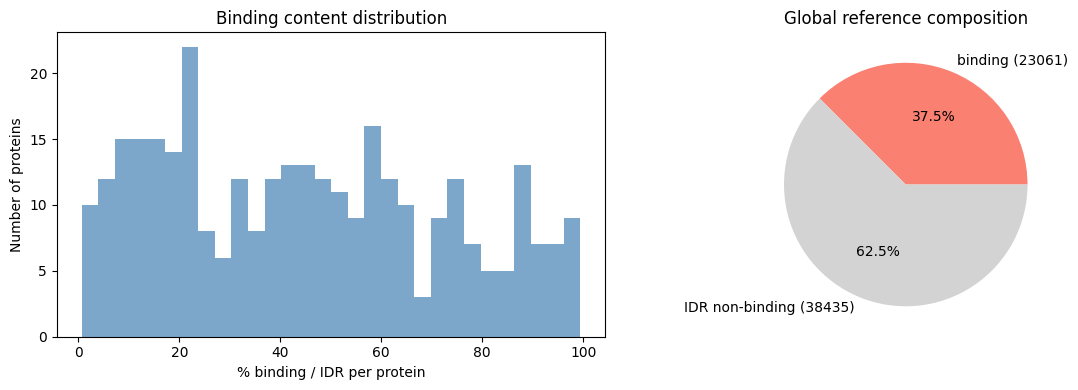

,disprot_id,n_binding,n_idr,pct_binding,pct_idr
0,DP00012,78,107,42.162162,57.837838
1,DP00023,9,43,17.307692,82.692308
2,DP00025,113,17,86.923077,13.076923
3,DP00027,57,40,58.762887,41.237113
4,DP00030,500,18,96.525097,3.474903
...,...,...,...,...,...
317,DP04328,25,341,6.830601,93.169399
318,DP04341,41,105,28.082192,71.917808
319,DP04378,98,146,40.163934,59.836066
320,DP04379,110,90,55.000000,45.000000


In [58]:
ref.plot_stats(ACTIVE_REF)

# CONFUSION MATRICES

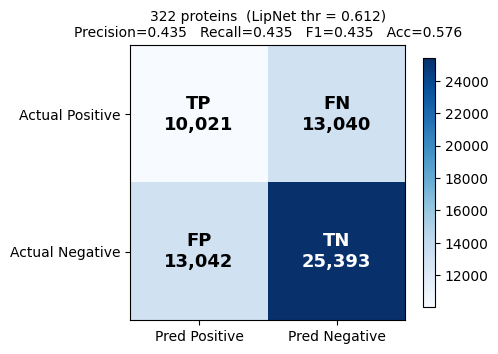

TP=10,021  FP=13,042  FN=13,040  TN=25,393
Precision=0.4345  Recall=0.4345  F1=0.4345  Accuracy=0.5759


In [59]:
# Confusion matrix — calcolata direttamente da ACTIVE_REF + score LipNet (NON usa merged_lip_af)
# Per cambiare reference: modifica ACTIVE nella cella "create reference" e riesegui questa.
import numpy as np
import matplotlib.pyplot as plt

LIPNET_THR = cfg["lip_score_thr"]   # soglia LipNet (da CONFIGS)

# score LipNet per residuo
_lip = lipnet_pred_df.rename(columns={'position': 'pos'})[['disprot_id', 'pos', 'lipnet_score']]

# reference (0/1/-) per residuo dalla ACTIVE_REF corrente
_rows = [(v['disprot_id'], i, ch)
         for v in ACTIVE_REF.values()
         for i, ch in enumerate(v['ref_sequence'], start=1)]
_ref_df = pd.DataFrame(_rows, columns=['disprot_id', 'pos', 'ref_seq'])

# join per-residuo reference <-> LipNet, solo posizioni annotate 0/1
_df  = _ref_df.merge(_lip, on=['disprot_id', 'pos'], how='inner')
_df  = _df[_df['ref_seq'].isin(['0', '1'])]
true = _df['ref_seq'].astype(int).to_numpy()
pred = (_df['lipnet_score'].to_numpy() >= LIPNET_THR).astype(int)

TP = int(((pred == 1) & (true == 1)).sum())
FP = int(((pred == 1) & (true == 0)).sum())
FN = int(((pred == 0) & (true == 1)).sum())
TN = int(((pred == 0) & (true == 0)).sum())

prec = TP / (TP + FP) if (TP + FP) else 0.0
rec  = TP / (TP + FN) if (TP + FN) else 0.0
f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
acc  = (TP + TN) / (TP + FP + FN + TN) if (TP + FP + FN + TN) else 0.0

cm = np.array([[TP, FN], [FP, TN]])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred Positive", "Pred Negative"], fontsize=10)
ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual Positive", "Actual Negative"], fontsize=10)
lab = [["TP", "FN"], ["FP", "TN"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{lab[i][j]}\n{cm[i, j]:,}", ha="center", va="center",
                fontsize=13, fontweight="bold",
                color="white" if cm[i, j] > cm.max() * 0.6 else "black")
ax.set_title(
    f"{_df['disprot_id'].nunique()} proteins  (LipNet thr = {LIPNET_THR:.3f})\n"
    f"Precision={prec:.3f}   Recall={rec:.3f}   F1={f1:.3f}   Acc={acc:.3f}",
    fontsize=10)
fig.tight_layout()
plt.show()

print(f"TP={TP:,}  FP={FP:,}  FN={FN:,}  TN={TN:,}")
print(f"Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}  Accuracy={acc:.4f}")


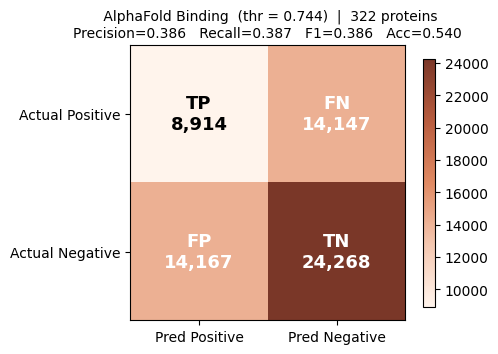

TP=8,914  FP=14,167  FN=14,147  TN=24,268
Precision=0.3862  Recall=0.3865  F1=0.3864  Accuracy=0.5396


In [60]:
# Confusion matrix AlphaFold Binding — autonoma, da ACTIVE_REF (NON dipende da merged_lip_af["ref_seq"])

AF_BINDING_THR = 0.744   # threshold AlphaFold

# reference (0/1/-) da ACTIVE_REF
_rows = [(v['disprot_id'], i, ch)
         for v in ACTIVE_REF.values()
         for i, ch in enumerate(v['ref_sequence'], start=1)]
_ref_df = pd.DataFrame(_rows, columns=['disprot_id', 'pos', 'ref_seq'])

# score AF binding per residuo (preso da merged_lip_af, dove 'binding' e' nativo)
_af = merged_lip_af.rename(columns={'pos': 'pos'})[['disprot_id', 'pos', 'binding']]

df_af = _ref_df.merge(_af, on=['disprot_id', 'pos'], how='inner')
df_af = df_af[df_af['ref_seq'].isin(['0', '1'])]
df_af['ref_bin'] = df_af['ref_seq'].astype(int)
df_af['af_pred'] = (df_af['binding'] >= AF_BINDING_THR).astype(int)

tp_af = int(((df_af['ref_bin'] == 1) & (df_af['af_pred'] == 1)).sum())
fp_af = int(((df_af['ref_bin'] == 0) & (df_af['af_pred'] == 1)).sum())
fn_af = int(((df_af['ref_bin'] == 1) & (df_af['af_pred'] == 0)).sum())
tn_af = int(((df_af['ref_bin'] == 0) & (df_af['af_pred'] == 0)).sum())

precision_af = tp_af / (tp_af + fp_af) if (tp_af + fp_af) else 0
recall_af    = tp_af / (tp_af + fn_af) if (tp_af + fn_af) else 0
f1_af        = 2 * precision_af * recall_af / (precision_af + recall_af) if (precision_af + recall_af) else 0
accuracy_af  = (tp_af + tn_af) / (tp_af + fp_af + fn_af + tn_af) if (tp_af + fp_af + fn_af + tn_af) else 0

cm_matrix_af = np.array([[tp_af, fn_af], [fp_af, tn_af]])
terracotta_cmap = LinearSegmentedColormap.from_list(
    "terracotta", ["#fff4ec", "#f4c7b0", "#e08a63", "#b85c3e", "#7a3728"])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_matrix_af, cmap=terracotta_cmap)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred Positive", "Pred Negative"], fontsize=10)
ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual Positive", "Actual Negative"], fontsize=10)
labels_pos = [["TP", "FN"], ["FP", "TN"]]
for i in range(2):
    for j in range(2):
        val = cm_matrix_af[i, j]
        ax.text(j, i, f"{labels_pos[i][j]}\n{val:,}", ha="center", va="center",
                fontsize=13, fontweight="bold",
                color="white" if val > cm_matrix_af.max() / 2 else "black")
ax.set_title(
    f" AlphaFold Binding  (thr = {AF_BINDING_THR})  |  {df_af['disprot_id'].nunique()} proteins\n"
    f"Precision={precision_af:.3f}   Recall={recall_af:.3f}   F1={f1_af:.3f}   Acc={accuracy_af:.3f}",
    fontsize=10)
fig.tight_layout()
plt.show()

print(f"TP={tp_af:,}  FP={fp_af:,}  FN={fn_af:,}  TN={tn_af:,}")
print(f"Precision={precision_af:.4f}  Recall={recall_af:.4f}  F1={f1_af:.4f}  Accuracy={accuracy_af:.4f}")


# CAID

# ROC AND PR CURVES

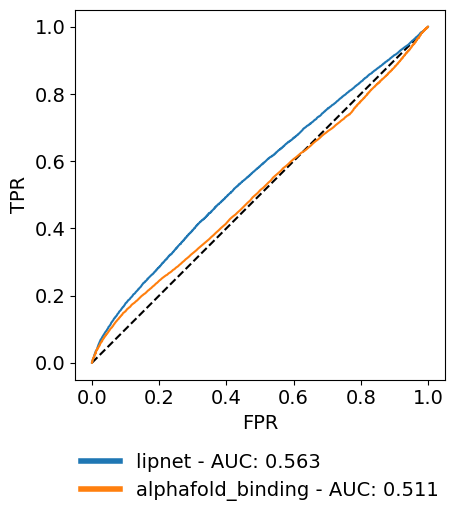

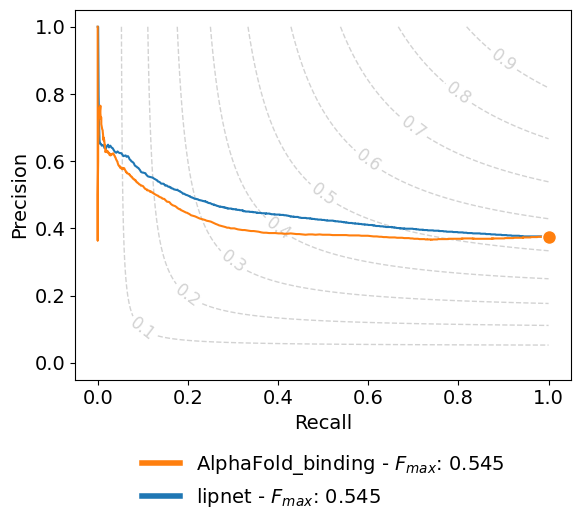

In [61]:
# Cell 24
# roc curve
CAID_OUTPUT_DIR = cfg["caid_output_dir"]
label = cfg["label"]

DO_B_roc = pd.read_csv(
    os.path.join(CAID_OUTPUT_DIR, f"{label}.analysis.all.dataset._.roc.csv"),
    index_col=[0], header=[0, 1, 2])
ax = plt.subplot()
ax.set_facecolor((1.0, 1, 1))
for spine in ax.spines.values():
    spine.set_edgecolor('black')
ax.set_box_aspect(1)
plots.plot_roc(DO_B_roc, ax=ax)

DO_B_pr = pd.read_csv(
    os.path.join(CAID_OUTPUT_DIR, f"{label}.analysis.all.dataset._.pr.csv"),
    index_col=[0], header=[0, 1, 2, 3])
plots.plot_pr(DO_B_pr)


# LOCALCIDER: create dictionary




In [62]:
# 3 region dictionaries: REF==1, TP-LipNet, FP-LipNet (over ACTIVE_REF)
# Same format as lipnet_pred_dict_all: 'lipnet_pred' = binary 0/1 mask aligned to 'prot_sequence'.
# cider.extract_predicted_regions extracts the contiguous '1' blocks -> NO change to cider.

lipnet_bin_by_id = (                       # disprot_id -> 0/1 string (LipNet prediction)
    lipnet_pred_df.sort_values(["disprot_id", "position"])
    .groupby("disprot_id")["lipnet_score"]
    .apply(lambda x: "".join((x >= LIPNET_THRESHOLD).astype(int).astype(str)))
    .to_dict()
)

def _mask_dict(kind):
    """kind in {'ref1','tp','fp'} -> {idx: {acc, disprot_id, prot_sequence, lipnet_pred}}"""
    out, skipped = {}, 0
    for idx, v in ACTIVE_REF.items():
        did, ref_seq, seq = v['disprot_id'], v['ref_sequence'], v['sequence']
        lip = lipnet_bin_by_id.get(did)
        if lip is None or len(lip) != len(ref_seq):   # alignment guard
            skipped += 1
            continue
        if kind == 'ref1':
            mask = ''.join('1' if r == '1' else '0' for r in ref_seq)
        elif kind == 'tp':
            mask = ''.join('1' if (l == '1' and r == '1') else '0' for l, r in zip(lip, ref_seq))
        elif kind == 'fp':
            mask = ''.join('1' if (l == '1' and r == '0') else '0' for l, r in zip(lip, ref_seq))
        out[idx] = {'acc': v['acc'], 'disprot_id': did,
                    'prot_sequence': seq, 'lipnet_pred': mask}
    if skipped:
        print(f"[{kind}] proteins skipped (no LipNet / length mismatch): {skipped}")
    return out

dict_ref1 = _mask_dict('ref1')   # reference binding regions (ref == '1')
dict_tp   = _mask_dict('tp')     # True Positive   (LipNet==1 & ref==1)
dict_fp   = _mask_dict('fp')     # False Positive  (LipNet==1 & ref==0)

# extract regions (same function as in the notebook) + filter invalid AAs
regions_ref1, _ = cider.filter_invalid(cider.extract_predicted_regions(dict_ref1))
regions_tp,   _ = cider.filter_invalid(cider.extract_predicted_regions(dict_tp))
regions_fp,   _ = cider.filter_invalid(cider.extract_predicted_regions(dict_fp))

for name, reg in [("REF==1", regions_ref1), ("TP", regions_tp), ("FP", regions_fp)]:
    print(f"{name:8}: {len(reg)} proteins, {sum(len(r) for r in reg.values())} regions")


REF==1  : 322 proteins, 396 regions
TP      : 322 proteins, 861 regions
FP      : 322 proteins, 1425 regions


=== REF==1 ===
count    396.0
mean      58.2
std       82.1
min        4.0
25%       14.0
50%       26.0
75%       72.2
max      555.0
Name: length, dtype: float64
Total regions: 396  |  length < 5: 7 (1.8%)

=== TP-LipNet ===
count    861.0
mean      11.6
std       17.0
min        1.0
25%        1.0
50%        4.0
75%       15.0
max      145.0
Name: length, dtype: float64
Total regions: 861  |  length < 5: 443 (51.5%)

=== FP-LipNet ===
count    1425.0
mean        9.2
std        15.6
min         1.0
25%         1.0
50%         3.0
75%        11.0
max       172.0
Name: length, dtype: float64
Total regions: 1425  |  length < 5: 869 (61.0%)



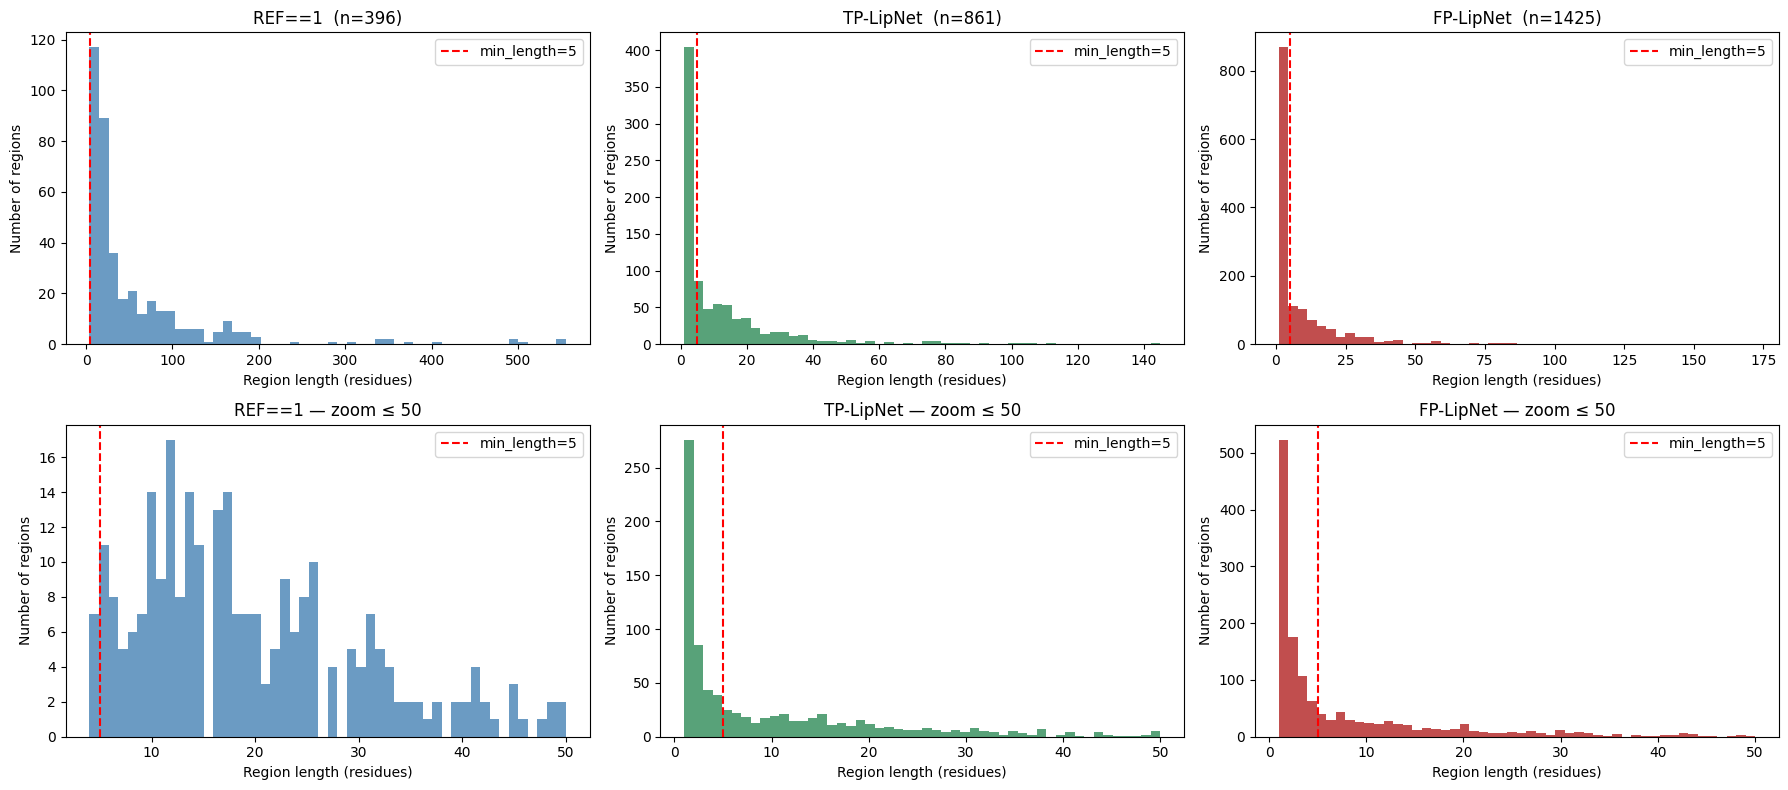

In [63]:
# Cell 13.5 - Region length distribution for the 3 groups: REF==1, TP-LipNet, FP-LipNet
groups = [
    ("REF==1",    regions_ref1, "steelblue"),
    ("TP-LipNet", regions_tp,   "seagreen"),
    ("FP-LipNet", regions_fp,   "firebrick"),
]

def _lengths(reg_dict):
    return pd.Series([r['length'] for regions in reg_dict.values() for r in regions], name='length')

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for j, (name, reg, color) in enumerate(groups):
    s = _lengths(reg)
    print(f"=== {name} ===")
    print(s.describe().round(1))
    n_short = (s < 5).sum()
    pct = (s < 5).mean() * 100 if len(s) else 0
    print(f"Total regions: {len(s)}  |  length < 5: {n_short} ({pct:.1f}%)\n")

    # full distribution (top row)
    axes[0, j].hist(s, bins=50, color=color, alpha=0.8)
    axes[0, j].axvline(5, color='red', linestyle='--', label='min_length=5')
    axes[0, j].set_title(f'{name}  (n={len(s)})')
    axes[0, j].set_xlabel('Region length (residues)'); axes[0, j].set_ylabel('Number of regions')
    axes[0, j].legend()

    # zoom <= 50 (bottom row)
    axes[1, j].hist(s[s <= 50], bins=50, color=color, alpha=0.8)
    axes[1, j].axvline(5, color='red', linestyle='--', label='min_length=5')
    axes[1, j].set_title(f'{name} — zoom \u2264 50')
    axes[1, j].set_xlabel('Region length (residues)'); axes[1, j].set_ylabel('Number of regions')
    axes[1, j].legend()

plt.tight_layout()

_fig_dir = os.path.join("..", "data", "processed", "figures", cfg["label"])
os.makedirs(_fig_dir, exist_ok=True)
fig.savefig(os.path.join(_fig_dir, "region_lengths_ref_tp_fp.png"), dpi=150, bbox_inches="tight")
plt.show()


## Compute CIDER 

In [64]:
# CIDER features for the 3 groups: REF==1, TP-LipNet, FP-LipNet
OUT_DIR = r"..\data\processed"

groups = [
    ("ref1", regions_ref1),   # reference binding (ref == 1)
    ("tp",   regions_tp),     # True Positive  (LipNet==1 & ref==1)
    ("fp",   regions_fp),     # False Positive (LipNet==1 & ref==0)
]

cider_dfs = {}
for name, reg in groups:
    reg_fs = cider.filter_short(reg, min_length=5)
    df = cider.compute_features(reg_fs)
    df.to_csv(os.path.join(OUT_DIR, f"df_cider_{name}.csv"), index=False)
    cider_dfs[name] = df
    print(f"{name:5}: proteins after filter_short (>=5 aa): {len(reg_fs)}  |  "
          f"proteins: {df['disprot_id'].nunique()}, regions: {len(df)}")

# comodità: variabili dedicate
df_cider_ref1 = cider_dfs["ref1"]
df_cider_tp   = cider_dfs["tp"]
df_cider_fp   = cider_dfs["fp"]


ref1 : proteins after filter_short (>=5 aa): 319  |  proteins: 319, regions: 389
tp   : proteins after filter_short (>=5 aa): 253  |  proteins: 253, regions: 418
fp   : proteins after filter_short (>=5 aa): 240  |  proteins: 240, regions: 556


In [65]:
# Extra compositional features added on top of cider.compute_features, for the 3 groups.
# add_extra_features(df): derives 4 columns from the existing CIDER columns / region_sequence —
#   frac_positive = (FCR + NCPR)/2, frac_negative = (FCR - NCPR)/2  (positive/negative charge split),
#   frac_polar    = share of S/T/N/Q residues, frac_proline = share of P residues.
def add_extra_features(df):
    df = df.copy()
    df["frac_positive"] = (df["FCR"] + df["NCPR"]) / 2
    df["frac_negative"] = (df["FCR"] - df["NCPR"]) / 2
    df["frac_polar"]    = df["region_sequence"].str.upper().apply(
        lambda s: sum(1 for aa in s if aa in "STNQ") / len(s))
    df["frac_proline"]  = df["region_sequence"].str.upper().apply(
        lambda s: s.count("P") / len(s))
    return df

df_cider_ref1_full = add_extra_features(df_cider_ref1)   # REF==1
df_cider_tp_full   = add_extra_features(df_cider_tp)      # TP
df_cider_fp_full   = add_extra_features(df_cider_fp)      # FP
print("Features added: frac_positive, frac_negative, frac_polar, frac_proline")

Features added: frac_positive, frac_negative, frac_polar, frac_proline


In [66]:
# Cell 18 — map the 3 CIDER groups (REF==1 / TP / FP) to the names used by the plot cells.
# The CIDER feature tables were already built upstream
# (cider.extract_predicted_regions -> filter_invalid -> filter_short -> compute_features
#  -> add_extra_features), so there is NO recomputation here: only aliasing + the `features` list.

LIP_SCORE_THRESHOLD = cfg["lip_score_thr"]   # LipNet score threshold used to define TP/FP

# group aliases used by the violin / distribution cells
ref_cider_DF = df_cider_ref1_full            # REF==1 : reference binding regions (ref == '1')
DF_LIP_tp    = df_cider_tp_full              # TP     : LipNet binding overlapping ref == '1'
DF_LIP_fp    = df_cider_fp_full              # FP     : LipNet binding on ref == '0'

# "all LipNet predicted" = TP + FP, kept for the inspection cell below
DF_LIP_pred_cider_af = pd.concat([DF_LIP_tp, DF_LIP_fp], ignore_index=True)
lip_pred_cider_DF    = DF_LIP_pred_cider_af

# feature columns = CIDER metrics shared by all groups (exclude metadata columns)
_meta = {'protein_id', 'disprot_id', 'start', 'end', 'length', 'region_sequence'}
features = [c for c in ref_cider_DF.columns
           if c not in _meta and c in DF_LIP_tp.columns and c in DF_LIP_fp.columns]

print(f"[{cfg['label']}] features: {features}")
for nm, d in [("REF==1", ref_cider_DF), ("TP", DF_LIP_tp), ("FP", DF_LIP_fp)]:
    print(f"{nm:7}: {d['disprot_id'].nunique()} proteins, {len(d)} regions")

[allowed_100] features: ['FCR', 'NCPR', 'kappa', 'Mean_hydropathy', 'PPII_propensity', 'seq_complexity_shannon', 'frac_aromatic', 'frac_bulky', 'frac_order_promoting', 'frac_positive', 'frac_negative', 'frac_polar', 'frac_proline']
REF==1 : 319 proteins, 389 regions
TP     : 253 proteins, 418 regions
FP     : 240 proteins, 556 regions


In [67]:
# Inspect the "all LipNet predicted" CIDER table (TP + FP regions concatenated in Cell 18).
DF_LIP_pred_cider_af

,protein_id,disprot_id,start,end,length,region_sequence,FCR,NCPR,kappa,Mean_hydropathy,PPII_propensity,seq_complexity_shannon,frac_aromatic,frac_bulky,frac_order_promoting,frac_positive,frac_negative,frac_polar,frac_proline
0,8,DP00012,803,819,17,TELDIYSRRLSQETGLE,0.352941,-0.117647,0.327170,3.600000,0.321176,0.776796,0.058824,0.235294,0.294118,0.117647,0.235294,0.294118,0.000000
1,16,DP00023,191,199,9,TAFMEKVLG,0.222222,0.000000,0.131507,5.166667,0.328889,1.000000,0.111111,0.333333,0.333333,0.111111,0.111111,0.111111,0.000000
2,18,DP00025,746,858,113,QNSGNQSFEEDTEEDKPKYEQGGNIVDIDFDSVPQIHGQNKGNQSF...,0.336283,-0.159292,0.257118,3.138053,0.364956,0.865373,0.088496,0.194690,0.300885,0.088496,0.247788,0.247788,0.053097
3,20,DP00027,41,97,57,VTLSDAQAKLMQPGVSDINMERVEALKTAIRNGELKMDTGKIADSL...,0.280702,0.000000,0.079443,4.108772,0.364035,0.894912,0.017544,0.228070,0.280702,0.140351,0.140351,0.245614,0.017544
4,23,DP00030,22,26,5,ERGDV,0.600000,-0.200000,-1.000000,2.960000,0.324000,1.000000,0.000000,0.200000,0.200000,0.200000,0.400000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
969,3167,DP04378,138,149,12,EGGIDFTPHNGT,0.166667,-0.166667,0.481959,3.616667,0.315000,0.842981,0.083333,0.166667,0.250000,0.000000,0.166667,0.250000,0.083333
970,3167,DP04378,578,593,16,RAEQITASVNELSESK,0.312500,-0.062500,0.222134,3.693750,0.362500,0.820160,0.000000,0.187500,0.250000,0.125000,0.187500,0.375000,0.000000
971,3167,DP04378,595,599,5,AELMA,0.200000,-0.200000,-1.000000,5.660000,0.352000,0.827729,0.000000,0.200000,0.200000,0.000000,0.200000,0.000000,0.000000
972,3168,DP04379,111,115,5,PLPLD,0.200000,-0.200000,-1.000000,4.680000,0.556000,0.655459,0.000000,0.400000,0.400000,0.000000,0.200000,0.000000,0.400000


## CIDER for AlphaFold-binding


In [68]:
# CIDER for AlphaFold-binding: build TP/FP region dictionaries from merged_lip_af.
# Pattern parallel to cell 35 (LipNet). dict_ref1 already exists upstream and is shared.
# AF score column: 'binding' (AlphaFold-binding from binding-25-0.581.dat).

AF_BINDING_THR = 0.744   # match cell 29 (AF binding threshold)

# disprot_id -> binary mask string (0/1) aligned by residue position
af_bin_by_id = (
    merged_lip_af.sort_values(["disprot_id", "pos"])
    .groupby("disprot_id")["binding"]
    .apply(lambda x: "".join((x >= AF_BINDING_THR).astype(int).astype(str)))
    .to_dict()
)

def _mask_dict_af(kind):
    """kind in {'tp','fp'} -> {idx: {acc, disprot_id, prot_sequence, lipnet_pred}}.
    Field name 'lipnet_pred' is kept for compatibility with cider.extract_predicted_regions
    (the function consumes a binary mask regardless of which predictor produced it)."""
    out, skipped = {}, 0
    for idx, v in ACTIVE_REF.items():
        did, ref_seq, seq = v['disprot_id'], v['ref_sequence'], v['sequence']
        afm = af_bin_by_id.get(did)
        if afm is None or len(afm) != len(ref_seq):
            skipped += 1
            continue
        if kind == 'tp':
            mask = ''.join('1' if (a == '1' and r == '1') else '0' for a, r in zip(afm, ref_seq))
        elif kind == 'fp':
            mask = ''.join('1' if (a == '1' and r == '0') else '0' for a, r in zip(afm, ref_seq))
        out[idx] = {'acc': v['acc'], 'disprot_id': did,
                    'prot_sequence': seq, 'lipnet_pred': mask}
    if skipped:
        print(f"[AF {kind}] proteins skipped (no AF / length mismatch): {skipped}")
    return out

dict_af_tp = _mask_dict_af('tp')   # AlphaFold-binding TP: AF==1 & ref==1
dict_af_fp = _mask_dict_af('fp')   # AlphaFold-binding FP: AF==1 & ref==0

# extract regions + filter invalid amino acids
regions_af_tp, _ = cider.filter_invalid(cider.extract_predicted_regions(dict_af_tp))
regions_af_fp, _ = cider.filter_invalid(cider.extract_predicted_regions(dict_af_fp))

for name, reg in [("AF-TP", regions_af_tp), ("AF-FP", regions_af_fp)]:
    print(f"{name:6}: {len(reg)} proteins, {sum(len(r) for r in reg.values())} regions")


AF-TP : 322 proteins, 1421 regions
AF-FP : 322 proteins, 2586 regions


In [69]:
# CIDER features for the 2 AlphaFold groups (AF-TP, AF-FP).
# Pattern parallel to cell 38 (LipNet). Includes a timer to verify scope/speed.
import time

af_groups = [
    ("af_tp", regions_af_tp),
    ("af_fp", regions_af_fp),
]

cider_af_dfs = {}
for name, reg in af_groups:
    reg_fs = cider.filter_short(reg, min_length=5)
    t0 = time.time()
    df = cider.compute_features(reg_fs)
    elapsed = time.time() - t0
    df.to_csv(os.path.join(OUT_DIR, f"df_cider_{name}.csv"), index=False)
    cider_af_dfs[name] = df
    print(f"{name:6}: proteins after filter_short (>=5 aa): {len(reg_fs)}  |  "
          f"proteins: {df['disprot_id'].nunique()}, regions: {len(df)}, "
          f"computed in {elapsed:.1f}s")

df_cider_af_tp = cider_af_dfs["af_tp"]
df_cider_af_fp = cider_af_dfs["af_fp"]


af_tp : proteins after filter_short (>=5 aa): 218  |  proteins: 218, regions: 422, computed in 2.5s
af_fp : proteins after filter_short (>=5 aa): 227  |  proteins: 227, regions: 691, computed in 3.4s


In [70]:
# Add extra compositional features (parallel to cell 40 for LipNet).
# Uses add_extra_features() defined upstream; produces frac_positive, frac_negative,
# frac_polar, frac_proline on top of cider.compute_features output.
df_cider_af_tp_full = add_extra_features(df_cider_af_tp)
df_cider_af_fp_full = add_extra_features(df_cider_af_fp)
print("AF features added: frac_positive, frac_negative, frac_polar, frac_proline")


AF features added: frac_positive, frac_negative, frac_polar, frac_proline


In [71]:
# AlphaFold aliases for the plot cells. Mirrors cell 41 (LipNet).

DF_AF_tp = df_cider_af_tp_full   # AF-TP : AF binding == 1 overlapping ref == 1
DF_AF_fp = df_cider_af_fp_full   # AF-FP : AF binding == 1 on ref == 0

# all AlphaFold-predicted = TP + FP (kept for global inspection)
DF_AF_pred_cider = pd.concat([DF_AF_tp, DF_AF_fp], ignore_index=True)

# feature columns shared by ref / AF-TP / AF-FP
features_af = [c for c in ref_cider_DF.columns
               if c not in _meta and c in DF_AF_tp.columns and c in DF_AF_fp.columns]

print(f"[AF binding thr={AF_BINDING_THR}] features: {features_af}")
for nm, d in [("REF==1", ref_cider_DF), ("AF-TP", DF_AF_tp), ("AF-FP", DF_AF_fp)]:
    print(f"{nm:7}: {d['disprot_id'].nunique()} proteins, {len(d)} regions")


[AF binding thr=0.744] features: ['FCR', 'NCPR', 'kappa', 'Mean_hydropathy', 'PPII_propensity', 'seq_complexity_shannon', 'frac_aromatic', 'frac_bulky', 'frac_order_promoting', 'frac_positive', 'frac_negative', 'frac_polar', 'frac_proline']
REF==1 : 319 proteins, 389 regions
AF-TP  : 218 proteins, 422 regions
AF-FP  : 227 proteins, 691 regions


# SS distribution 
(normalized)

In [72]:
# Build a per-residue reference table from ACTIVE_REF and attach ref_seq to merged_lip_af.
#   pd.DataFrame.from_dict(ACTIVE_REF) + .explode(...) -> one row per residue (acc, disprot_id, pos, ref_seq).
#   .merge(how='left') -> adds the 'ref_seq' column ('0'/'1'/'-') to merged_lip_af, aligned on acc+disprot_id+pos.
# WARNING: this mutates merged_lip_af IN PLACE; re-running after changing ACTIVE can duplicate the
#          column (ref_seq_x / ref_seq_y). The plot cells below instead rebuild from merged_lip_af_base.
seq_df = (
    pd.DataFrame.from_dict(ACTIVE_REF, orient='index')
    .reset_index(drop=True)
    .assign(aa      = lambda df: df['sequence'].apply(list),
            ref_seq = lambda df: df['ref_sequence'].apply(list),
            pos     = lambda df: df['aa'].apply(lambda x: list(range(1, len(x)+1))))
    .explode(['aa','ref_seq','pos'])
    [['acc','disprot_id','pos','ref_seq']]
    .astype({'pos': int})
)
merged_lip_af = merged_lip_af.merge(
    seq_df, on=['acc','disprot_id','pos'], how='left')

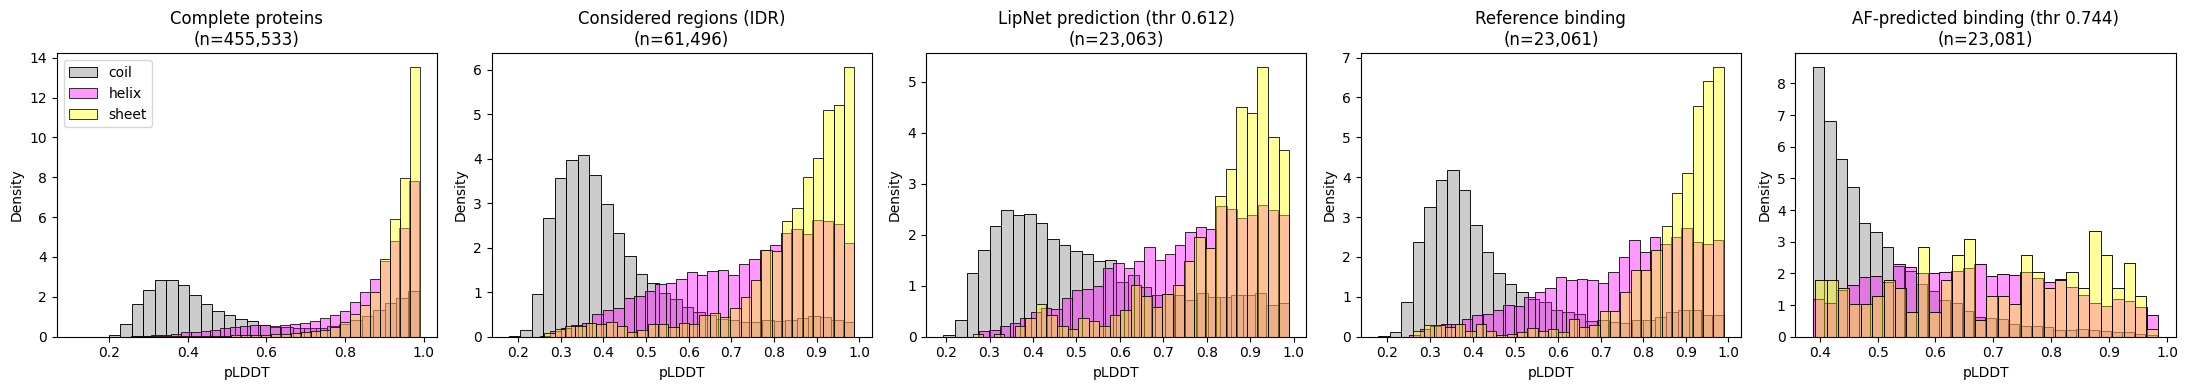

In [73]:
# pLDDT distribution by secondary structure across 5 residue subsets, reactive to ACTIVE.
#   Rebuilds ref_seq from ACTIVE_REF and LEFT-merges it onto a clean copy of merged_lip_af_base
#   (avoids the in-place "sticky" merge above). sns.histplot(..., stat="density") overlays the
#   coil/helix/sheet distributions of 'lddt' (raw pLDDT) for each subset; figure saved per cfg['label'].
palette = {"coil": "gray", "helix": "magenta", "sheet": "yellow"}

# per-residue ref_seq from the active reference, joined onto a clean copy of the base table
_ref_df = pd.DataFrame(
    [(v['disprot_id'], i, ch)
     for v in ACTIVE_REF.values()
     for i, ch in enumerate(v['ref_sequence'], start=1)],
    columns=['disprot_id', 'pos', 'ref_seq'])
mdf = merged_lip_af_base.merge(_ref_df, on=['disprot_id', 'pos'], how='left')

# the 5 subsets, all derived from mdf (consistent with ACTIVE)
datasets = [
    ("Complete proteins",                               mdf),
    ("Considered regions (IDR)",                        mdf[mdf["ref_seq"].isin(["0", "1"])]),
    (f"LipNet prediction (thr {LIPNET_THRESHOLD:.3f})", mdf[(mdf["lipnet_pred"] == 1) & (mdf["ref_seq"].isin(["0", "1"]))]),
    ("Reference binding",                               mdf[mdf["ref_seq"] == "1"]),
    (f"AF-predicted binding (thr {AF_BINDING_THR:.3f})", mdf[(mdf["binding"] >= AF_BINDING_THR) & (mdf["ref_seq"].isin(["0", "1"]))]),
]

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (title, df) in zip(axes, datasets):
    for ss in ["coil", "helix", "sheet"]:
        sns.histplot(df[df["ss_norm"] == ss]["lddt"], bins=30, kde=False,
                     color=palette[ss], label=ss, alpha=0.4, ax=ax, stat="density")
    ax.set_title(f"{title}\n(n={len(df):,})")
    ax.set_xlabel("pLDDT")
axes[0].set_ylabel("Density")
axes[0].legend()
plt.tight_layout()

_fig_dir = os.path.join("..", "data", "processed", "figures", cfg["label"])
os.makedirs(_fig_dir, exist_ok=True)
fig.savefig(os.path.join(_fig_dir, "ss_plddt_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

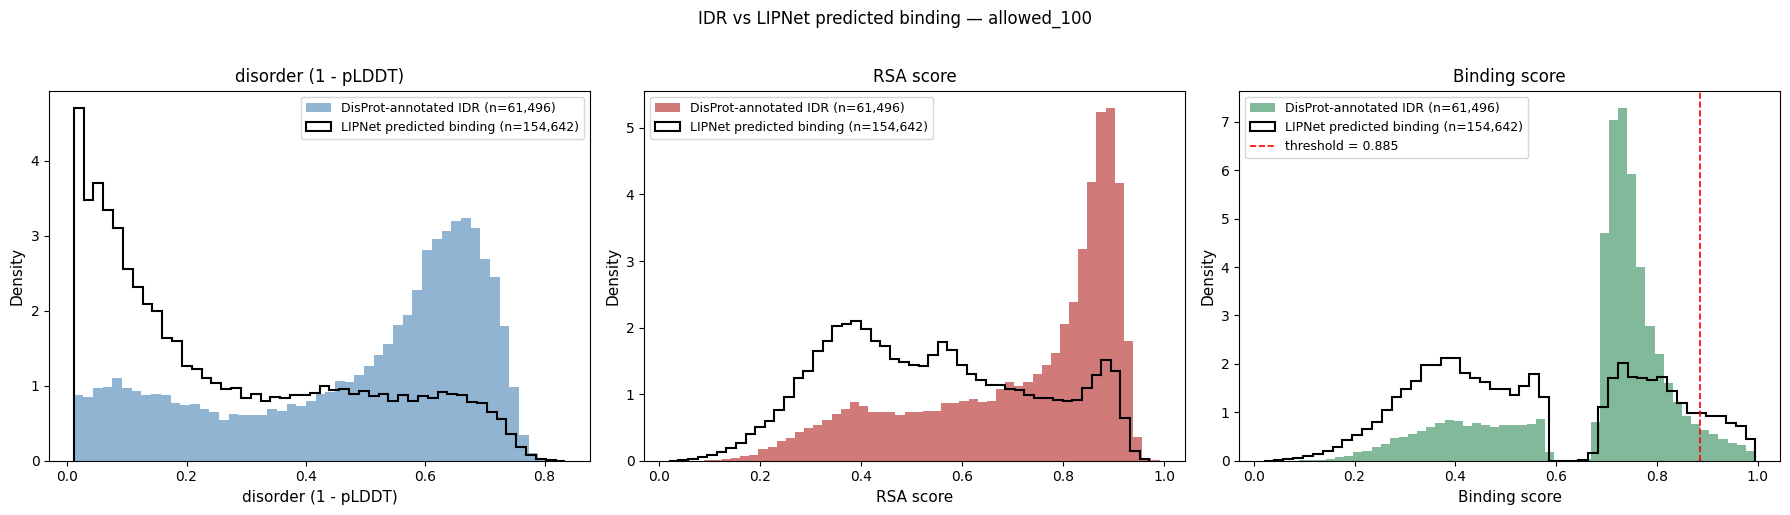


Metric             p-value    r_rb          Size
----------------------------------------------------
disorder        0.0000e+00   0.507         large
RSA             0.0000e+00   0.483        medium
Binding         0.0000e+00   0.267         small


In [74]:
# Compare structural metrics between DisProt-annotated IDR vs LipNet-predicted binding residues.
#   ref_seq is rebuilt from ACTIVE_REF and merged onto merged_lip_af_base (reactive to ACTIVE).
#   idr_pdb   = residues inside an annotated IDR region (ref_seq in {'0','1'}).
#   ones_pred = residues predicted binding by LipNet (lipnet_pred == 1).
#   For each metric (disorder=1-pLDDT, RSA, AF binding): overlaid density histograms +
#   scipy mannwhitneyu (distribution difference) and rank-biserial effect size r_rb.
_ref_df = pd.DataFrame(
    [(v['disprot_id'], i, ch)
     for v in ACTIVE_REF.values()
     for i, ch in enumerate(v['ref_sequence'], start=1)],
    columns=['disprot_id', 'pos', 'ref_seq'])
mdf = merged_lip_af_base.merge(_ref_df, on=['disprot_id', 'pos'], how='left')

idr_pdb   = mdf[mdf['ref_seq'].isin(['0', '1'])]   # residues inside an annotated IDR region
ones_pred = mdf[mdf['lipnet_pred'] == 1]           # residues predicted binding by LipNet

bins = 50
metrics = [
    ('disorder_plddt', 'disorder (1 - pLDDT)', 'steelblue'),   # NB: it's 1-pLDDT, not pLDDT
    ('disorder_rsa',   'RSA score',            'firebrick'),
    ('binding',        'Binding score',        'seagreen'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (col, xlabel, color) in zip(axes, metrics):
    ax.hist(idr_pdb[col].dropna(), bins=bins, color=color, alpha=0.6, density=True,
            label=f'DisProt-annotated IDR (n={idr_pdb[col].notna().sum():,})')
    ax.hist(ones_pred[col].dropna(), bins=bins, histtype='step', color='black',
            linewidth=1.5, density=True,
            label=f'LIPNet predicted binding (n={ones_pred[col].notna().sum():,})')
    if col == 'binding':
        ax.axvline(0.885, color='red', linestyle='--', linewidth=1.2, label='threshold = 0.885')
    ax.set_xlabel(xlabel, fontsize=11); ax.set_ylabel('Density', fontsize=11)
    ax.set_title(xlabel, fontsize=12); ax.legend(fontsize=9)

fig.suptitle(f'IDR vs LIPNet predicted binding — {cfg["label"]}', fontsize=12, y=1.02)
plt.tight_layout()

_fig_dir = os.path.join("..",
                        "data", "processed", "figures", cfg["label"])
os.makedirs(_fig_dir, exist_ok=True)
fig.savefig(os.path.join(_fig_dir, 'hist_rsa_binding_plddt_density.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'Metric':<12}  {'p-value':>12}  {'r_rb':>6}  {'Size':>12}")
print("-" * 52)
for col, xlabel in [('disorder_plddt', 'disorder'), ('disorder_rsa', 'RSA'), ('binding', 'Binding')]:
    a, b   = idr_pdb[col].dropna(), ones_pred[col].dropna()
    U, p   = mannwhitneyu(a, b, alternative='two-sided')
    r_rb   = abs(1 - 2 * U / (len(a) * len(b)))
    size_lbl = ('large' if r_rb >= 0.5 else 'medium' if r_rb >= 0.3 else
                'small' if r_rb >= 0.1 else 'negligible')
    print(f"{xlabel:<12}  {p:>12.4e}  {r_rb:>6.3f}  {size_lbl:>12}")

# Violin plot  
## chemical composition predicted regions   

LIPNet

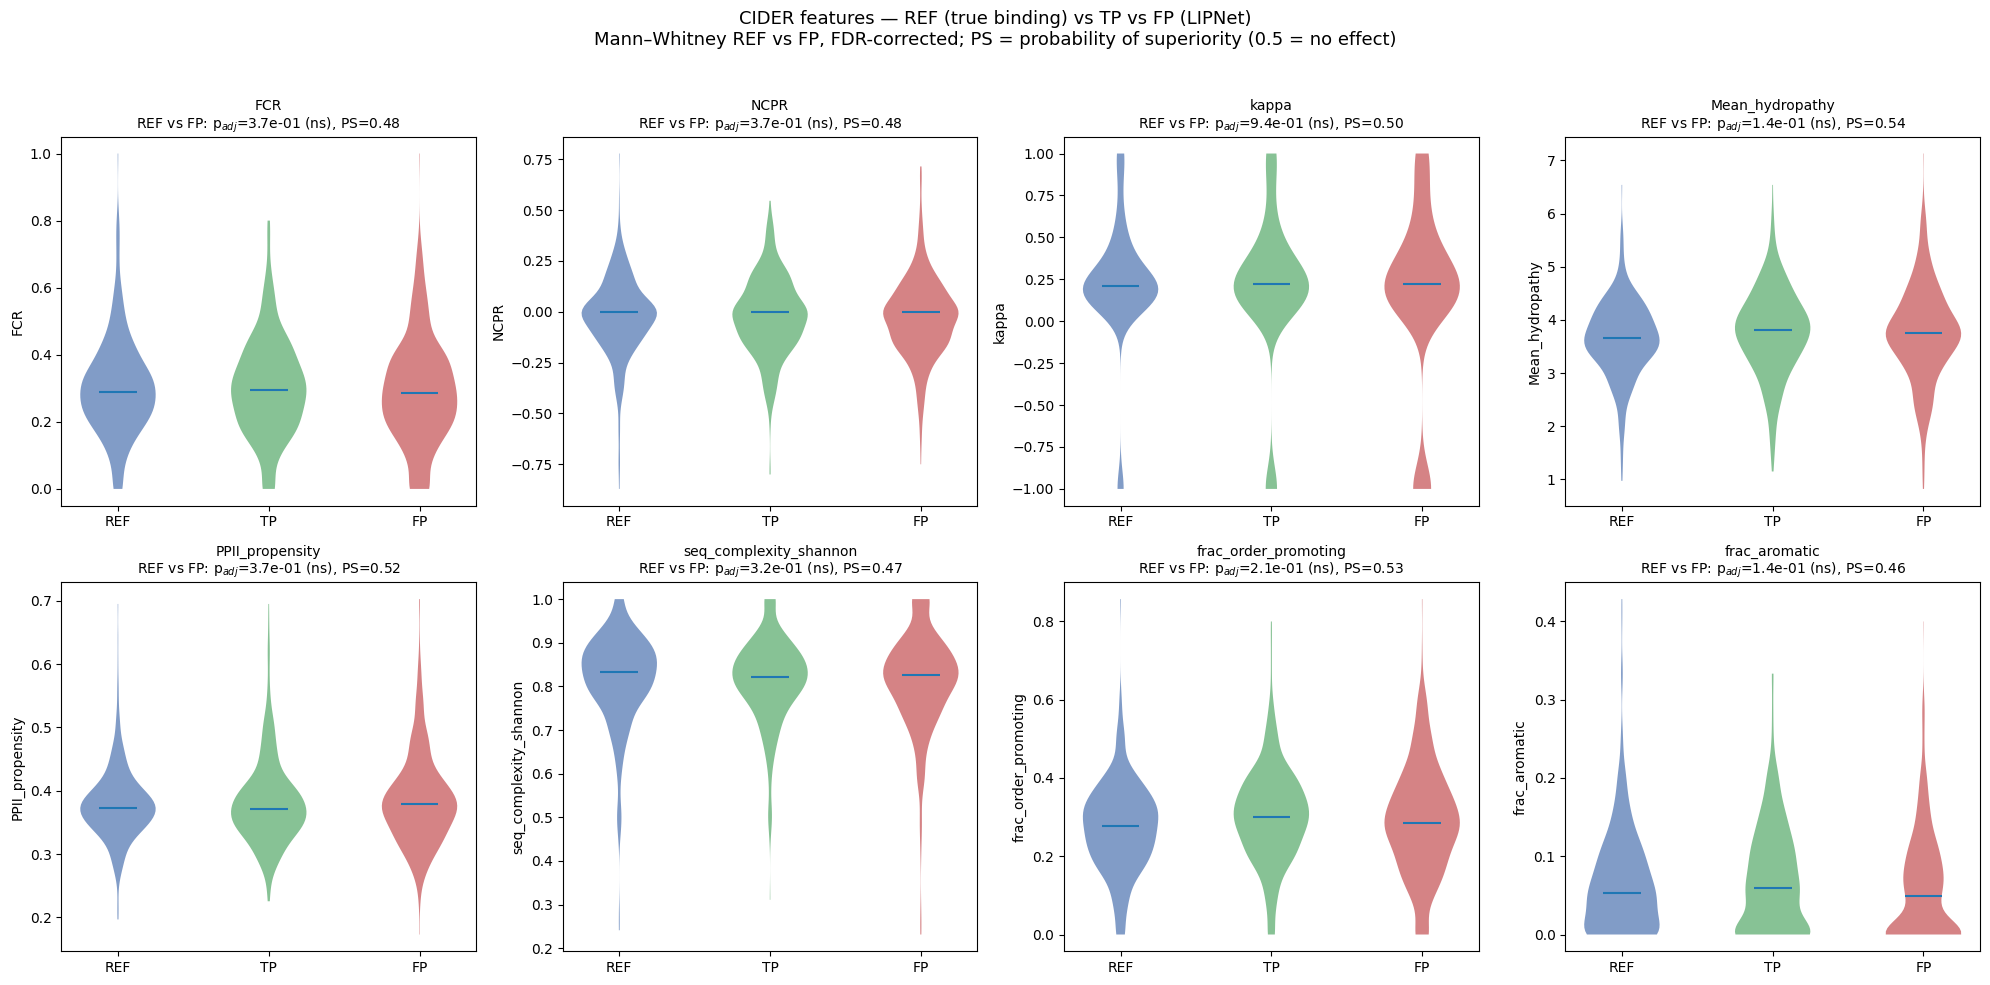

feature                      p_raw     p_adj  sig  PS(FP>REF)
FCR                       2.79e-01  3.72e-01   ns       0.479
NCPR                      2.51e-01  3.72e-01   ns       0.478
kappa                     9.40e-01  9.40e-01   ns       0.499
Mean_hydropathy           3.56e-02  1.42e-01   ns       0.540
PPII_propensity           3.26e-01  3.73e-01   ns       0.519
seq_complexity_shannon    1.62e-01  3.23e-01   ns       0.473
frac_order_promoting      7.83e-02  2.09e-01   ns       0.534
frac_aromatic             2.52e-02  1.42e-01   ns       0.458


In [75]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Le 8 feature definitive (NON le 13)
FEATURES = ['FCR', 'NCPR', 'kappa', 'Mean_hydropathy', 'PPII_propensity',
            'seq_complexity_shannon', 'frac_order_promoting', 'frac_aromatic']

groups = {'REF': df_cider_ref1, 'TP': df_cider_tp, 'FP': df_cider_fp}
colors = {'REF': '#4C72B0', 'TP': '#55A868', 'FP': '#C44E52'}

# --- 1. Effect size: probabilità di superiorità (common-language) ---
def prob_superiority(a, b):
    """P(x>y) + 0.5*P(x=y); 0.5 = nessuna differenza. Da Mann-Whitney U."""
    a, b = np.asarray(a), np.asarray(b)
    U, _ = mannwhitneyu(a, b, alternative='two-sided')
    return U / (len(a) * len(b))

# --- 2. Test REF vs FP per ogni feature, con raccolta p-value per correzione ---
pvals, effects = [], []
for f in FEATURES:
    ref = df_cider_ref1[f].dropna().values
    fp  = df_cider_fp[f].dropna().values
    _, p = mannwhitneyu(ref, fp, alternative='two-sided')
    pvals.append(p)
    effects.append(prob_superiority(fp, ref))   # P(FP > REF)

# correzione per test multipli (Benjamini-Hochberg / FDR)
reject, pvals_corr, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')

# --- 3. Plot: 8 pannelli, 3 violini ciascuno ---
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, f in enumerate(FEATURES):
    ax = axes[i]
    data = [groups[g][f].dropna().values for g in ['REF', 'TP', 'FP']]
    parts = ax.violinplot(data, showmedians=True, showextrema=False)
    for j, g in enumerate(['REF', 'TP', 'FP']):
        parts['bodies'][j].set_facecolor(colors[g])
        parts['bodies'][j].set_alpha(0.7)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['REF', 'TP', 'FP'])
    ax.set_ylabel(f)

    # titolo: p corretto REF-vs-FP + effect size
    sig = '*' if reject[i] else 'ns'
    ax.set_title(f"{f}\nREF vs FP: p$_{{adj}}$={pvals_corr[i]:.1e} ({sig}), "
                 f"PS={effects[i]:.2f}", fontsize=10)

fig.suptitle("CIDER features — REF (true binding) vs TP vs FP (LIPNet)\n"
             "Mann–Whitney REF vs FP, FDR-corrected; PS = probability of superiority (0.5 = no effect)",
             fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("cider_violins_ref_tp_fp.png", dpi=150, bbox_inches='tight')
plt.show()

# --- 4. Tabella riassuntiva per la tesi ---
print(f"{'feature':<24}{'p_raw':>10}{'p_adj':>10}{'sig':>5}{'PS(FP>REF)':>12}")
for i, f in enumerate(FEATURES):
    print(f"{f:<24}{pvals[i]:>10.2e}{pvals_corr[i]:>10.2e}"
          f"{'*' if reject[i] else 'ns':>5}{effects[i]:>12.3f}")

In [ ]:
# --- LIPNet: i 3 effetti significativi (violin plots mirati) ---
# order-promoting (TP vs REF), mean hydropathy (TP vs REF), aromatic (TP vs FP)
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

groups = {'REF': df_cider_ref1, 'TP': df_cider_tp, 'FP': df_cider_fp}
colors = {'REF': '#4C72B0', 'TP': '#55A868', 'FP': '#C44E52'}
order  = ['REF', 'TP', 'FP']

# (feature, gruppo1, gruppo2, etichetta leggibile) -> PS = P(gruppo1 > gruppo2)
specs = [
    ('frac_order_promoting', 'TP', 'REF', 'Order-promoting fraction'),
    ('Mean_hydropathy',      'TP', 'REF', 'Mean hydropathy'),
    ('frac_aromatic',        'TP', 'FP',  'Aromatic fraction'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (feat, g1, g2, label) in zip(axes, specs):
    data  = [groups[g][feat].dropna().values for g in order]
    parts = ax.violinplot(data, showmeans=False, showmedians=True, showextrema=False)

    # le due categorie confrontate in evidenza, la terza attenuata come contesto
    for pc, g in zip(parts['bodies'], order):
        highlight = g in (g1, g2)
        pc.set_facecolor(colors[g])
        pc.set_alpha(0.85 if highlight else 0.22)
        pc.set_edgecolor('black' if highlight else 'none')
        pc.set_linewidth(1.0 if highlight else 0.0)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(1.2)

    ax.set_xticks([1, 2, 3]); ax.set_xticklabels(order)
    ax.set_ylabel(feat)

    a = groups[g1][feat].dropna().values
    b = groups[g2][feat].dropna().values
    ps   = prob_superiority(a, b)                       # P(g1 > g2)
    _, p = mannwhitneyu(a, b, alternative='two-sided')  # p pairwise grezzo
    ax.set_title(f"{label}\n{g1} vs {g2}:  PS={ps:.2f}  (p={p:.1e})", fontsize=11)

fig.suptitle("LIPNet - i 3 effetti significativi  |  PS = probability of superiority (0.5 = nessun effetto)",
             fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


Alphafold-binding

AF-TP: 185 proteins, 315 regions | AF-FP: 178 proteins, 437 regions


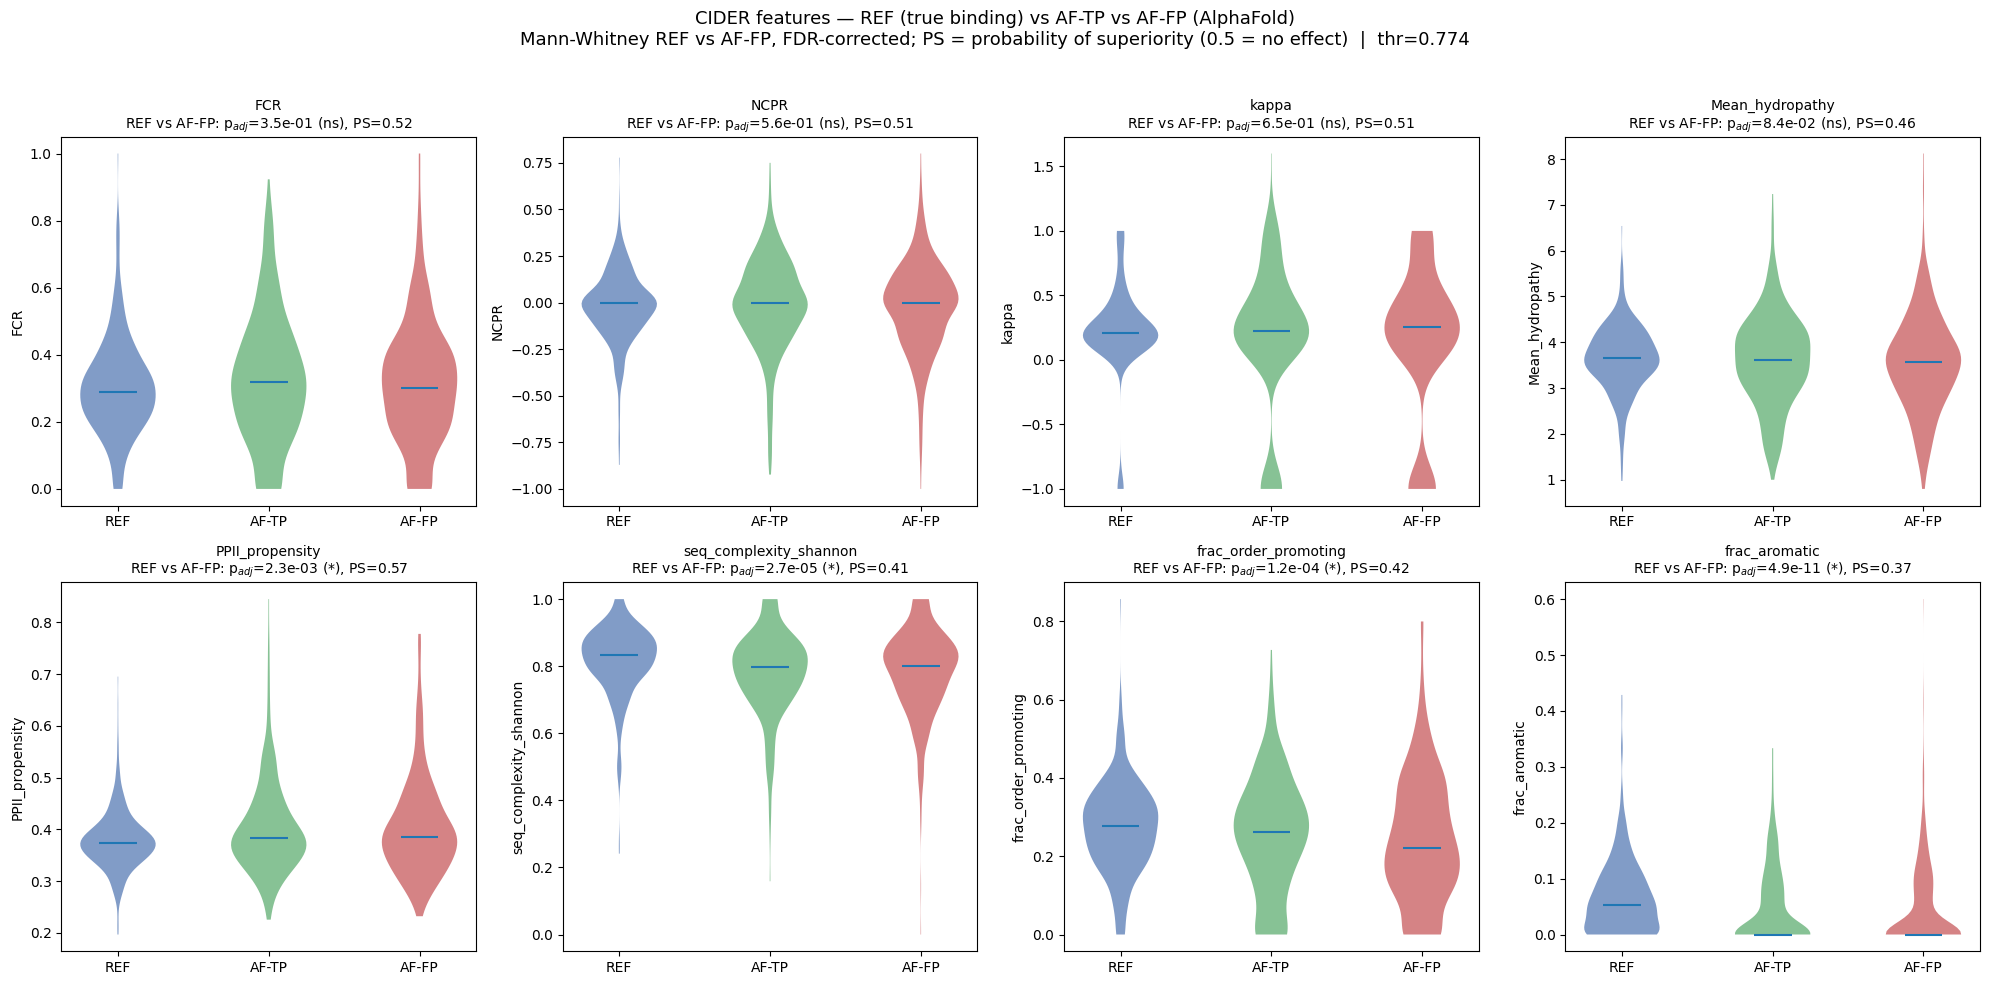

feature                      p_raw     p_adj  sig  PS(AF-FP>REF)
FCR                       2.66e-01  3.54e-01   ns          0.522
NCPR                      4.90e-01  5.60e-01   ns          0.514
kappa                     6.49e-01  6.49e-01   ns          0.509
Mean_hydropathy           5.27e-02  8.43e-02   ns          0.461
PPII_propensity           1.15e-03  2.29e-03    *          0.565
seq_complexity_shannon    6.82e-06  2.73e-05    *          0.409
frac_order_promoting      4.43e-05  1.18e-04    *          0.418
frac_aromatic             6.18e-12  4.94e-11    *          0.367


In [ ]:
# CIDER features — REF vs AlphaFold-TP vs AlphaFold-FP  (AF analogue of the LipNet REF/TP/FP cell)
# Builds AF TP/FP region groups from the per-residue AlphaFold 'binding' score, computes CIDER features
# (cider.extract_predicted_regions -> filter_invalid -> filter_short -> compute_features),
# then plots one violin per feature and tests REF vs AF-FP (Mann-Whitney + BH-FDR, no statsmodels).
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

AF_BINDING_THR = 0.744   # AlphaFold binding threshold (same as the AF confusion matrix)

# --- 0. AF TP/FP region dicts, then their CIDER feature tables ---
_af_pred = {(d, p): (b >= AF_BINDING_THR)
            for d, p, b in merged_lip_af_base[['disprot_id', 'pos', 'binding']].itertuples(index=False)}

def _af_mask_dict(kind):
    out = {}
    for idx, v in ACTIVE_REF.items():
        did, ref_seq, seq = v['disprot_id'], v['ref_sequence'], v['sequence']
        mask = []
        for i, r in enumerate(ref_seq, start=1):
            af = _af_pred.get((did, i), False)      # missing AF score -> not predicted
            if kind == 'tp':
                mask.append('1' if (af and r == '1') else '0')   # AF==1 & ref==1
            else:
                mask.append('1' if (af and r == '0') else '0')   # AF==1 & ref==0
        out[idx] = {'acc': v['acc'], 'disprot_id': did,
                    'prot_sequence': seq, 'lipnet_pred': ''.join(mask)}
    return out

def _cider_for(d):
    reg, _ = cider.filter_invalid(cider.extract_predicted_regions(d))
    reg    = cider.filter_short(reg, min_length=5)
    return cider.compute_features(reg)

df_cider_af_tp = _cider_for(_af_mask_dict('tp'))
df_cider_af_fp = _cider_for(_af_mask_dict('fp'))
print(f"AF-TP: {df_cider_af_tp['disprot_id'].nunique()} proteins, {len(df_cider_af_tp)} regions | "
      f"AF-FP: {df_cider_af_fp['disprot_id'].nunique()} proteins, {len(df_cider_af_fp)} regions")

# --- Benjamini-Hochberg FDR (no statsmodels) ---
def bh_fdr(pvals, alpha=0.05):
    p = np.asarray(pvals, float); n = len(p)
    order = np.argsort(p)
    ranked = p[order] * n / np.arange(1, n + 1)
    p_sorted = np.minimum.accumulate(ranked[::-1])[::-1]
    p_adj = np.empty(n); p_adj[order] = np.clip(p_sorted, 0, 1)
    return p_adj < alpha, p_adj

FEATURES = ['FCR', 'NCPR', 'kappa', 'Mean_hydropathy', 'PPII_propensity',
            'seq_complexity_shannon', 'frac_order_promoting', 'frac_aromatic']
groups = {'REF': df_cider_ref1, 'TP': df_cider_af_tp, 'FP': df_cider_af_fp}
colors = {'REF': '#4C72B0', 'TP': '#55A868', 'FP': '#C44E52'}

def prob_superiority(a, b):
    a, b = np.asarray(a), np.asarray(b)
    U, _ = mannwhitneyu(a, b, alternative='two-sided')
    return U / (len(a) * len(b))

pvals, effects = [], []
for f in FEATURES:
    ref = df_cider_ref1[f].dropna().values
    fp  = df_cider_af_fp[f].dropna().values
    _, p = mannwhitneyu(ref, fp, alternative='two-sided')
    pvals.append(p)
    effects.append(prob_superiority(fp, ref))   # P(AF-FP > REF)

reject, pvals_corr = bh_fdr(pvals, alpha=0.05)

fig, axes = plt.subplots(2, 4, figsize=(20, 10)); axes = axes.flatten()
for i, f in enumerate(FEATURES):
    ax = axes[i]
    data = [groups[g][f].dropna().values for g in ['REF', 'TP', 'FP']]
    parts = ax.violinplot(data, showmedians=True, showextrema=False)
    for j, g in enumerate(['REF', 'TP', 'FP']):
        parts['bodies'][j].set_facecolor(colors[g]); parts['bodies'][j].set_alpha(0.7)
    ax.set_xticks([1, 2, 3]); ax.set_xticklabels(['REF', 'AF-TP', 'AF-FP']); ax.set_ylabel(f)
    sig = '*' if reject[i] else 'ns'
    ax.set_title(f"{f}\nREF vs AF-FP: p$_{{adj}}$={pvals_corr[i]:.1e} ({sig}), PS={effects[i]:.2f}", fontsize=10)

fig.suptitle("CIDER features — REF (true binding) vs AF-TP vs AF-FP (AlphaFold)\n"
             f"Mann-Whitney REF vs AF-FP, FDR-corrected; PS = probability of superiority (0.5 = no effect)  |  thr={AF_BINDING_THR}",
             fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("cider_violins_ref_af_tp_fp.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"{'feature':<24}{'p_raw':>10}{'p_adj':>10}{'sig':>5}{'PS(AF-FP>REF)':>15}")
for i, f in enumerate(FEATURES):
    print(f"{f:<24}{pvals[i]:>10.2e}{pvals_corr[i]:>10.2e}"
          f"{'*' if reject[i] else 'ns':>5}{effects[i]:>15.3f}")


## Metriche threshold-free — LIPNet vs AlphaFold-binding (binding-IDR, allowed_100)

Cella **appesa** (non modifica le celle precedenti). Calcola, sui residui valutabili (label 0/1) della reference `allowed_100`, le metriche indipendenti dalla soglia per i due predittori: AUC-ROC con **IC 95% (DeLong)**, AUC-PR (**APS**) e il **test di DeLong** sulla differenza delle due AUC-ROC (residui appaiati). È *self-contained*: legge la reference e gli score `INPUT_CAID` dai file (gli stessi input delle confusion matrix), quindi è indipendente da `ACTIVE_REF` in memoria. Le funzioni stanno in `src_functions/delong_utils.py`; i risultati sono salvati in `data/processed/`.

In [77]:
# === [CELLA APPESA] Metriche threshold-free: LIPNet vs AlphaFold-binding (binding-IDR, allowed_100) ===
# Self-contained: legge la reference allowed_100 e gli score INPUT_CAID direttamente
# (gli stessi input usati per le confusion matrix), indipendente da ACTIVE_REF in memoria.
# AUC-ROC + IC 95% (DeLong), AUC-PR (APS), test di DeLong fra le due AUC-ROC.
import os, sys
sys.path.insert(0, r"../src")
import importlib, delong_utils as du
importlib.reload(du)

BASE = r".."
REF = os.path.join(BASE, "data/processed/reference/allowed_100.fasta")
LIP = os.path.join(BASE, "data/processed/INPUT_CAID/lipnet.caid")
AF  = os.path.join(BASE, "data/processed/INPUT_CAID/alphafold_binding.caid")

res = du.threshold_free_compare(REF, LIP, AF, names=("lipnet", "alphafold_binding"))
print(du.format_report(res, REF, LIP, AF))

# persistenza su data/processed/
OUT_CSV = os.path.join(BASE, "data/processed/disprot_bindingidr_threshold_free_metrics.csv")
OUT_TXT = os.path.join(BASE, "data/processed/disprot_bindingidr_threshold_free_metrics.txt")
res["df"].to_csv(OUT_CSV, index=False)
with open(OUT_TXT, "w", encoding="utf-8") as fh:
    fh.write(du.format_report(res, REF, LIP, AF))
    fh.write(chr(10))
print()
print("Salvati:")
print(" ", OUT_CSV)
print(" ", OUT_TXT)
res["df"]


Threshold-free metrics — DisProt binding-IDR (allowed_100, 322 proteine)
predictor             AUC-ROC  95% CI (DeLong)      AUC-PR(APS)   n_res  n_prot
lipnet                 0.5625  [0.5578, 0.5673]          0.4483   61496     322
alphafold_binding      0.5111  [0.5063, 0.5159]          0.4135   61496     322

DeLong (AUC-ROC lipnet - alphafold_binding, residui appaiati): ΔAUC=+0.0514  z=15.3995  p=1.649e-53 (bilaterale)

Provenance:
  reference (label 0/1/-): ..\data/processed/reference/allowed_100.fasta
  score lipnet            : ..\data/processed/INPUT_CAID/lipnet.caid (colonna 3)
  score alphafold_binding : ..\data/processed/INPUT_CAID/alphafold_binding.caid (colonna 3)
  AUC-ROC, IC 95%, ΔAUC/z/p : fast DeLong (Sun & Xu 2014) su 61496 residui appaiati
  AUC-PR                    : Average Precision Score
Coverage / invarianti:
  proteine reference=322  coperte da lipnet=322  da alphafold_binding=322
  residui valutabili=61496  (con score lipnet=61496, alphafold_binding=61496, e

,predictor,auc_roc,ci95_low,ci95_high,auc_pr_aps,n_residues,n_positives,n_negatives,n_proteins
0,lipnet,0.5625,0.5578,0.5673,0.4483,61496,23061,38435,322
1,alphafold_binding,0.5111,0.5063,0.5159,0.4135,61496,23061,38435,322


## CIDER — tutte le coppie (TP/FP/REF) per LIPNet e AlphaFold + FDR globale e per-famiglia

Cella **appesa** (non modifica le celle precedenti). Estende le due celle violin CIDER: per ogni **metodo** (LIPNet, AlphaFold), ognuno dei **3 confronti a coppie** (TP vs FP, TP vs REF, FP vs REF) e ognuna delle **8 feature** → 2×3×8 = **48 test**. Per ogni test: Mann-Whitney U (two-sided, p grezzo), probabilità di superiorità (effect size, 0.5 = nessun effetto) con direzione esplicita, n regioni per gruppo. FDR **Benjamini-Hochberg** applicata sia **globalmente** (48 test) sia **per-famiglia** (method, comparison; 8 test) → colonne separate `p_adj_global` / `p_adj_family` e flag `sig_global` / `sig_family`. Funzioni in `src_functions/cider_stats.py`; tabella salvata in `data/processed/cider_allpairs_results.csv`. La cella usa i DataFrame in memoria (`df_cider_ref1/tp/fp`, `df_cider_af_tp/fp`) se presenti, altrimenti carica i CSV persistiti dei gruppi.

In [78]:
# === [CELLA APPESA] CIDER tutte le coppie + FDR globale e per-famiglia ===
# 2 metodi x 3 confronti (TP vs FP, TP vs REF, FP vs REF) x 8 feature = 48 test.
# Mann-Whitney U (two-sided), prob. di superiorita' (con direzione), n regioni per gruppo.
# FDR Benjamini-Hochberg: globale (48) e per-famiglia (method, comparison; 8).
import os, sys
sys.path.insert(0, r"../src")
import importlib, cider_stats as cs
importlib.reload(cs)
import pandas as pd

FEATURES = ['FCR','NCPR','kappa','Mean_hydropathy','PPII_propensity',
            'seq_complexity_shannon','frac_order_promoting','frac_aromatic']
DATA = r"../data/processed"

# Usa i gruppi in memoria se la cella e' eseguita dopo le celle violin; altrimenti i CSV persistiti.
def _grp(varname, csv):
    v = globals().get(varname)
    return v if isinstance(v, pd.DataFrame) else pd.read_csv(os.path.join(DATA, csv))

groups = {
  'LIPNet':    {'REF': _grp('df_cider_ref1','df_cider_ref1.csv'),
                'TP':  _grp('df_cider_tp','df_cider_tp.csv'),
                'FP':  _grp('df_cider_fp','df_cider_fp.csv')},
  'AlphaFold': {'REF': _grp('df_cider_ref1','df_cider_ref1.csv'),
                'TP':  _grp('df_cider_af_tp','df_cider_af_tp.csv'),
                'FP':  _grp('df_cider_af_fp','df_cider_af_fp.csv')},
}

res = cs.compute_allpairs(groups, FEATURES)
OUT = os.path.join(DATA, "cider_allpairs_results.csv")
res.to_csv(OUT, index=False)

pd.set_option('display.width', 220, 'display.max_columns', 20, 'display.max_rows', 60)
shown = res.sort_values('p_adj_global').reset_index(drop=True)
print(shown.to_string(index=False))
print()
print(cs.summary_text(res, small_n=20))
print()
print("Salvato:", OUT)
shown


   method comparison                feature  n_group1  n_group2        p_raw  p_adj_global  p_adj_family  sig_global  sig_family  prob_superiority direction
AlphaFold  FP vs REF          frac_aromatic       437       389 6.175216e-12  2.964104e-10  4.940173e-11        True        True            0.3674    REF>FP
AlphaFold  TP vs REF          frac_aromatic       315       389 1.339493e-07  3.214784e-06  1.071595e-06        True        True            0.3880    REF>TP
AlphaFold  TP vs REF seq_complexity_shannon       315       389 8.761204e-07  1.401793e-05  3.504481e-06        True        True            0.3923    REF>TP
AlphaFold  FP vs REF seq_complexity_shannon       437       389 6.823367e-06  8.188041e-05  2.729347e-05        True        True            0.4094    REF>FP
AlphaFold  FP vs REF   frac_order_promoting       437       389 4.428604e-05  4.251460e-04  1.180961e-04        True        True            0.4178    REF>FP
   LIPNet  TP vs REF   frac_order_promoting       418     

,method,comparison,feature,n_group1,n_group2,p_raw,p_adj_global,p_adj_family,sig_global,sig_family,prob_superiority,direction
0,AlphaFold,FP vs REF,frac_aromatic,437,389,6.175216e-12,2.964104e-10,4.940173e-11,True,True,0.3674,REF>FP
1,AlphaFold,TP vs REF,frac_aromatic,315,389,1.339493e-07,3.214784e-06,1.071595e-06,True,True,0.3880,REF>TP
2,AlphaFold,TP vs REF,seq_complexity_shannon,315,389,8.761204e-07,1.401793e-05,3.504481e-06,True,True,0.3923,REF>TP
3,AlphaFold,FP vs REF,seq_complexity_shannon,437,389,6.823367e-06,8.188041e-05,2.729347e-05,True,True,0.4094,REF>FP
4,AlphaFold,FP vs REF,frac_order_promoting,437,389,4.428604e-05,4.251460e-04,1.180961e-04,True,True,0.4178,REF>FP
5,LIPNet,TP vs REF,frac_order_promoting,418,389,1.239996e-04,9.919971e-04,9.919971e-04,True,True,0.5781,TP>REF
6,AlphaFold,FP vs REF,PPII_propensity,437,389,1.146951e-03,7.864808e-03,2.293902e-03,True,True,0.5655,FP>REF
7,AlphaFold,TP vs REF,PPII_propensity,315,389,4.505809e-03,2.703485e-02,1.201549e-02,True,True,0.5622,TP>REF
8,LIPNet,TP vs FP,frac_aromatic,418,556,7.128977e-03,3.802121e-02,5.703182e-02,True,False,0.5490,TP>FP
9,LIPNet,TP vs REF,Mean_hydropathy,418,389,8.063318e-03,3.870393e-02,3.225327e-02,True,True,0.5539,TP>REF


## Figura tesi — i 3 effetti CIDER significativi sotto FDR globale

Cella **appesa** (non modifica le celle precedenti). Violini dei **soli 3 confronti significativi sotto BH-FDR globale** dell'analisi all-pairs (`cider_allpairs_results.csv`): (1) LIPNet `frac_order_promoting` TP vs REF, (2) LIPNet `frac_aromatic` TP vs FP, (3) AlphaFold `frac_aromatic` FP vs REF. Ogni pannello mostra solo i due gruppi del confronto; `p_adj(global)` e `PS` sono **letti dal CSV** (i titoli combaciano con la tabella). Niente feature non significative né risultati family-only. Figura salvata in `data/processed/cider_violins_significant_global.png`.

LIPNet    TP vs REF frac_order_promoting    REF: n=389  LIPNet TP: n=418
LIPNet    TP vs FP  frac_aromatic           LIPNet TP: n=418  LIPNet FP: n=556
AlphaFold FP vs REF frac_aromatic           REF: n=389  AlphaFold FP: n=437
Salvato: ../data/processed\cider_violins_significant_global.png


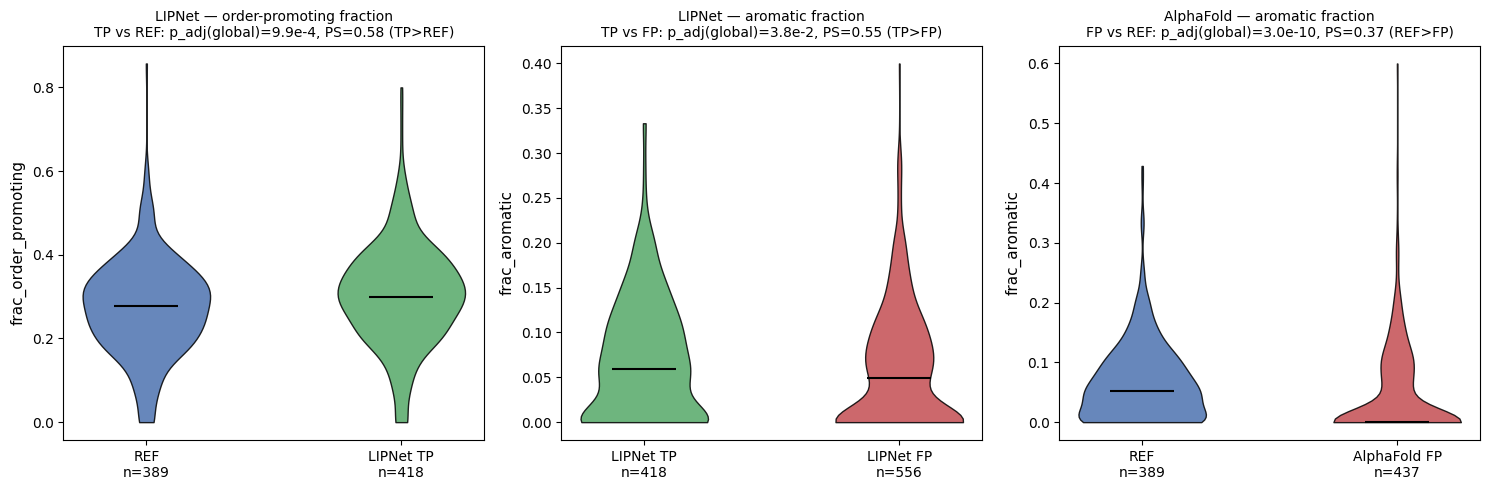

In [79]:
# === [CELLA APPESA] Figura tesi: solo i 3 effetti significativi sotto FDR globale ===
import os
import pandas as pd, numpy as np, matplotlib.pyplot as plt

DATA = r"../data/processed"
res = pd.read_csv(os.path.join(DATA, "cider_allpairs_results.csv"))

# usa i gruppi in memoria se presenti (cella eseguita dopo le celle violin), altrimenti i CSV
def _grp(varname, csv):
    v = globals().get(varname)
    return v if isinstance(v, pd.DataFrame) else pd.read_csv(os.path.join(DATA, csv))
REF   = _grp('df_cider_ref1', 'df_cider_ref1.csv')
LIPTP = _grp('df_cider_tp',   'df_cider_tp.csv')
LIPFP = _grp('df_cider_fp',   'df_cider_fp.csv')
AFFP  = _grp('df_cider_af_fp','df_cider_af_fp.csv')

C_REF, C_TP, C_FP = '#4C72B0', '#55A868', '#C44E52'   # come nelle celle violin
FEAT_NAME = {'frac_order_promoting': 'order-promoting fraction',
             'frac_aromatic': 'aromatic fraction'}

def read_stats(method, comparison, feature):
    r = res[(res.method == method) & (res.comparison == comparison) & (res.feature == feature)].iloc[0]
    return float(r.p_adj_global), float(r.prob_superiority), str(r.direction)

def fmt_p(p):
    mant, exp = f"{p:.1e}".split('e')
    return f"{mant}e{int(exp)}"   # es. 2.3e-4

# i 3 pannelli = i 3 risultati significativi sotto FDR globale
panels = [
    dict(method='LIPNet',    comparison='TP vs REF', feature='frac_order_promoting',
         groups=[('REF', REF, C_REF), ('LIPNet TP', LIPTP, C_TP)]),
    dict(method='LIPNet',    comparison='TP vs FP',  feature='frac_aromatic',
         groups=[('LIPNet TP', LIPTP, C_TP), ('LIPNet FP', LIPFP, C_FP)]),
    dict(method='AlphaFold', comparison='FP vs REF', feature='frac_aromatic',
         groups=[('REF', REF, C_REF), ('AlphaFold FP', AFFP, C_FP)]),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, P in zip(axes, panels):
    p_adj, ps, direction = read_stats(P['method'], P['comparison'], P['feature'])
    arrays = [np.asarray(g[1][P['feature']].dropna(), float) for g in P['groups']]
    colors = [g[2] for g in P['groups']]
    labels = [f"{g[0]}\nn={len(a)}" for g, a in zip(P['groups'], arrays)]
    vp = ax.violinplot(arrays, showmedians=True, showextrema=False)
    for body, c in zip(vp['bodies'], colors):
        body.set_facecolor(c); body.set_edgecolor('black'); body.set_alpha(0.85)
    if 'cmedians' in vp:
        vp['cmedians'].set_color('black'); vp['cmedians'].set_linewidth(1.5)
    ax.set_xticks([1, 2]); ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel(P['feature'], fontsize=11)
    ax.set_title(f"{P['method']} — {FEAT_NAME[P['feature']]}\n"
                 f"{P['comparison']}: p_adj(global)={fmt_p(p_adj)}, PS={ps:.2f} ({direction})",
                 fontsize=10)
    print(f"{P['method']:9s} {P['comparison']:9s} {P['feature']:22s}  "
          + "  ".join(f"{g[0]}: n={len(a)}" for g, a in zip(P['groups'], arrays)))

fig.tight_layout()
OUT = os.path.join(DATA, "cider_violins_significant_global.png")
fig.savefig(OUT, dpi=150, bbox_inches='tight')
print("Salvato:", OUT)
plt.show()


## Analisi strutturale — binding-IDR (pLDDT/disorder, RSA, struttura secondaria)

Cella **appesa** (non modifica le celle precedenti). Sui 61.496 residui valutabili di `ACTIVE_REF` (allowed_100) confronta 3 gruppi — **LIPNet_pred** (lipnet≥0.612), **REF_pos** (ref==1), **AF_pred** (binding≥0.744; soglie equal-count, convenzione ≥ inline). **(A)** Continui (pLDDT/disorder, RSA): mediane per gruppo + Mann-Whitney U two-sided con rank-biserial e direzione, sulle 3 coppie. **Flag di circolarità**: AlphaFold-binding è definito da RSA+pLDDT, quindi i suoi risultati pLDDT/RSA sono *by-construction*, non indipendenti. **(B)** Struttura secondaria (3 classi helix/sheet/coil): % per gruppo + chi-quadro + Cramér's V (NON circolare). **(C)** BH-FDR globale su tutti i 9 test (A+B). Funzioni in `src_functions/structural_stats.py`; risultati e figure in `data/processed/`.

SETUP / invarianti:
  residui=61496 (61496:True)  positivi=23061 (23061:True)  negativi=38435  proteine=322
  NaN lddt/rsa/ss=0/0/0  NaN lip/af=0/0  ss3_unmapped=0
Provenance: pLDDT='lddt', RSA='rsa', SS='ss' da alphafold_disorder_pred_caid_data.tsv; ref da allowed_100.fasta; lipnet/binding da INPUT_CAID/*.caid.

Gruppi (n, flag <50):
  LIPNet_pred  n=23063
  REF_pos      n=23061
  AF_pred      n=23081

=== (A) Continui — mediane per gruppo ===
      group     n  median_pLDDT  median_disorder  median_RSA
LIPNet_pred 23063         0.614            0.386       0.692
    REF_pos 23061         0.464            0.536       0.800
    AF_pred 23081         0.490            0.510       0.840

=== (A) Continui — test a coppie (MWU two-sided, BH-FDR globale) ===
variable                   pair  median_group1  median_group2         p_raw         p_adj  rank_biserial           direction  interpretation
     RSA LIPNet_pred vs AF_pred          0.692          0.840  0.000000e+00  0.000000e+00       

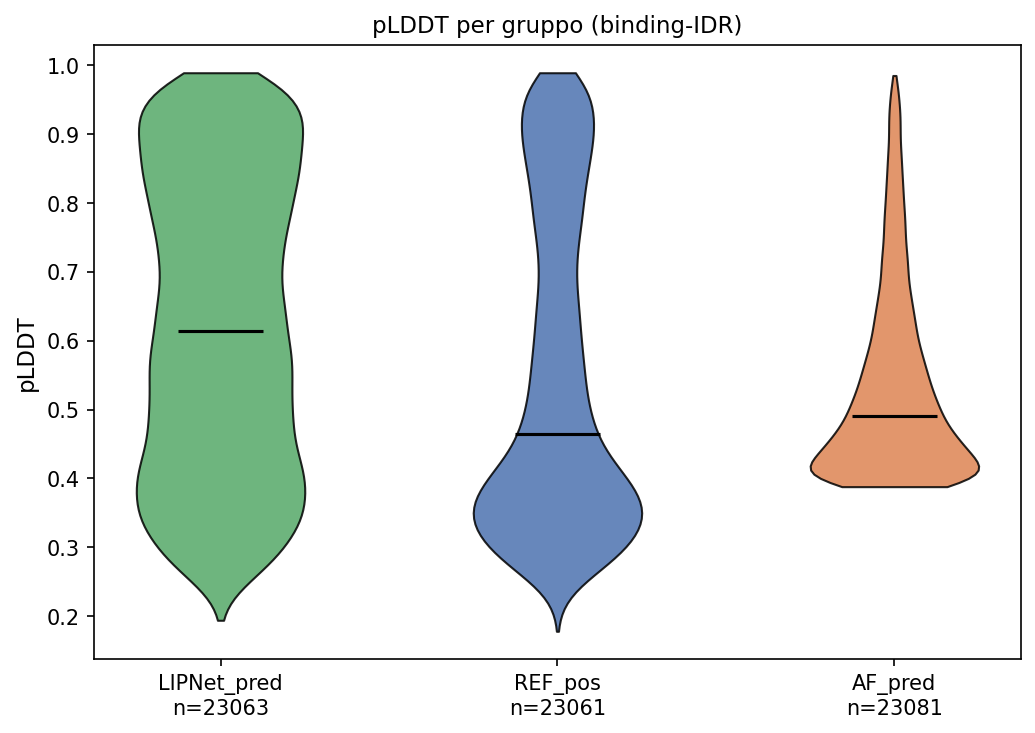

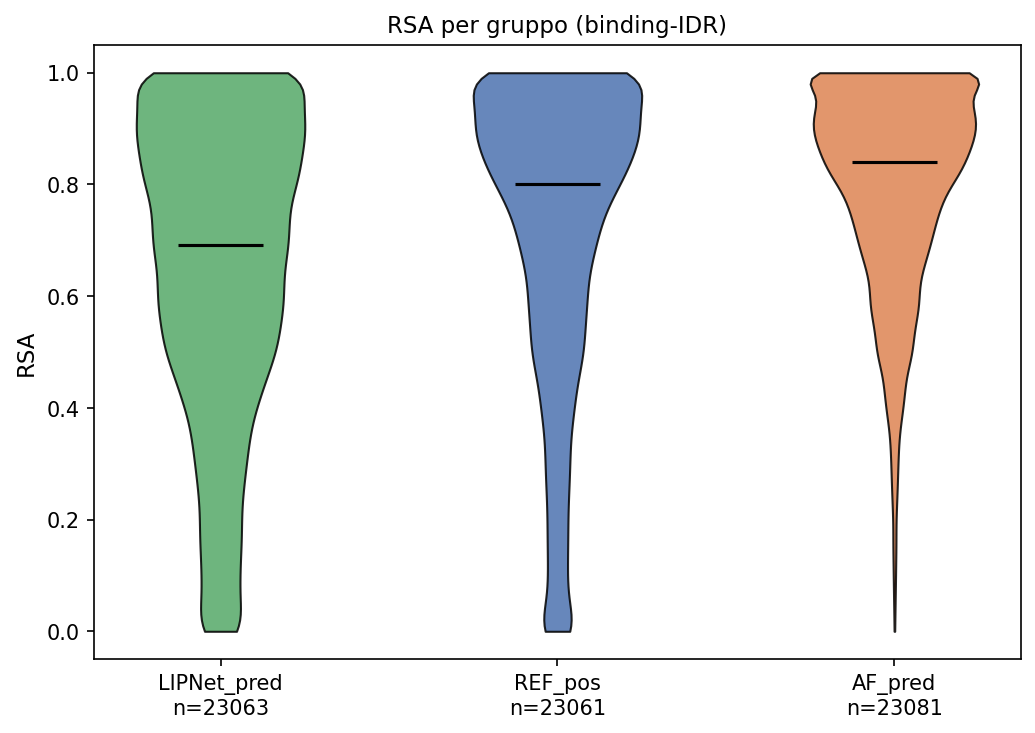

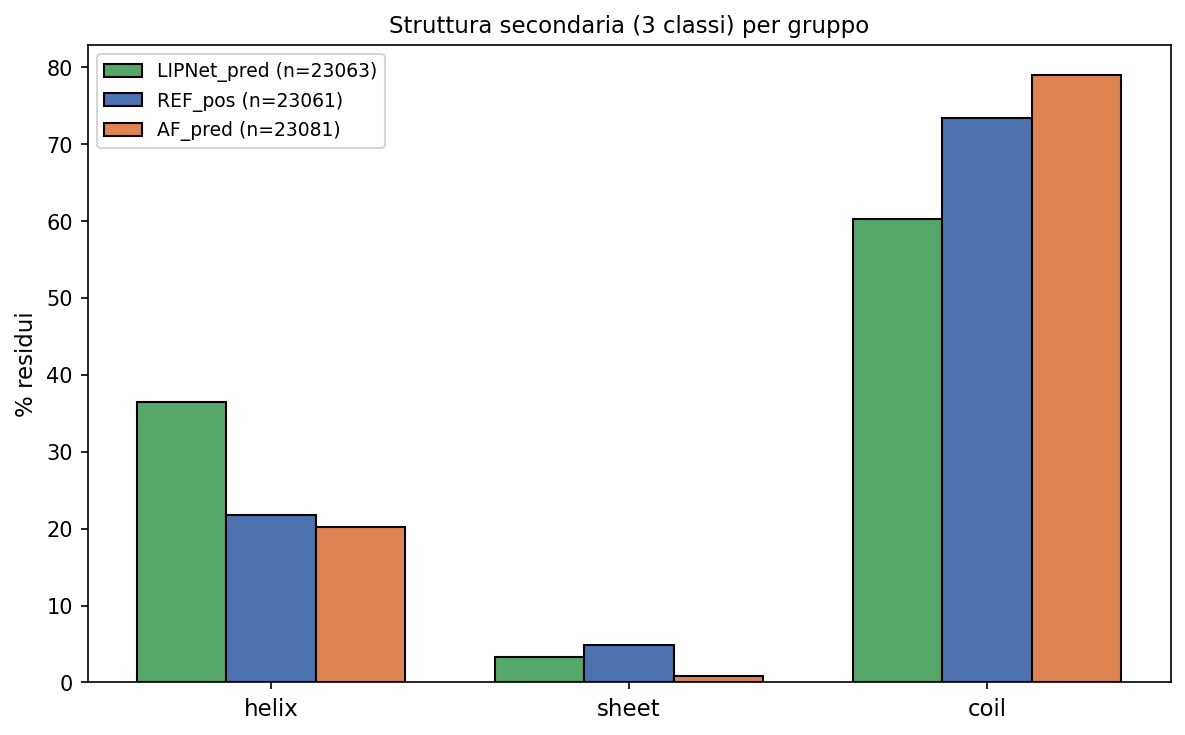

In [ ]:
# === [CELLA APPESA] Analisi strutturale binding-IDR: pLDDT/disorder, RSA, SS ===
# Self-contained: legge reference allowed_100, score INPUT_CAID e la TSV AlphaFold-disorder.
# Gruppi (convenzione >=, soglie equal-count): LIPNet_pred lipnet>=0.612, REF_pos ref==1, AF_pred binding>=0.744.
import os, sys
sys.path.insert(0, r"../src")
import importlib, structural_stats as st
importlib.reload(st)
import pandas as pd, matplotlib.pyplot as plt

BASE = r".."; DATA = os.path.join(BASE, "data/processed")
REF = os.path.join(DATA, "reference/allowed_100.fasta")
LIP = os.path.join(DATA, "INPUT_CAID/lipnet.caid")
AF  = os.path.join(DATA, "INPUT_CAID/alphafold_binding.caid")
TSV = os.path.join(BASE, "data/raw/Alphafold_CAID_output/alphafold_disorder_pred_caid_data.tsv")
JSON= os.path.join(BASE, "data/raw/DisProt_release_2025_06.json")

df, info = st.load_structural(REF, LIP, AF, TSV, JSON)
print("SETUP / invarianti:")
print(f"  residui={info['n_res']} (61496:{info['n_res']==61496})  positivi={info['n_pos']} (23061:{info['n_pos']==23061})  negativi={info['n_neg']}  proteine={info['n_prot']}")
print(f"  NaN lddt/rsa/ss={info['nan_lddt']}/{info['nan_rsa']}/{info['nan_ss']}  NaN lip/af={info['nan_lip']}/{info['nan_af']}  ss3_unmapped={info['ss3_unmapped']}")
print("Provenance: pLDDT='lddt', RSA='rsa', SS='ss' da alphafold_disorder_pred_caid_data.tsv; ref da allowed_100.fasta; lipnet/binding da INPUT_CAID/*.caid.")

groups = st.define_groups(df)
print("\nGruppi (n, flag <50):")
for g, m in groups.items():
    n=int(m.sum()); print(f"  {g:12s} n={n}{'  *** <50 ***' if n<50 else ''}")

gsum, cont = st.continuous_tests(df, groups)
gpct, ss   = st.ss_tests(df, groups)
cont, ss   = st.apply_global_fdr(cont, ss)   # BH-FDR globale su (A)+(B): 6+3=9 test

print("\n=== (A) Continui — mediane per gruppo ===")
print(gsum.to_string(index=False))
print("\n=== (A) Continui — test a coppie (MWU two-sided, BH-FDR globale) ===")
print(cont[['variable','pair','median_group1','median_group2','p_raw','p_adj','rank_biserial','direction','interpretation']].sort_values(['variable','p_adj']).to_string(index=False))
print("\nNOTA CIRCOLARITA': AlphaFold-binding e' definito da RSA e pLDDT -> pLDDT/RSA che coinvolgono")
print("AF_pred sono un 'by-construction check' (interpretation=by-construction), NON un risultato")
print("indipendente. Gli informativi su pLDDT/RSA sono LIPNet_pred vs REF_pos.")

print("\n=== (B) Struttura secondaria — % helix/sheet/coil per gruppo ===")
print(gpct.to_string(index=False))
print("\n=== (B) SS — chi-quadro 3 classi a coppie (BH-FDR globale) ===")
print(ss[['pair','chi2','dof','p_raw','p_adj','cramers_v','sig_global']].to_string(index=False))
print("(SS NON e' circolare: non entra nella formula di AlphaFold-binding; tutti e 3 i gruppi sono validi.")
print(" I LIP tendono a SS quasi-uniforme e alta frazione coil; REF_pos e' il riferimento empirico.)")

cont.to_csv(os.path.join(DATA,"structural_continuous_results.csv"), index=False)
ss.to_csv(os.path.join(DATA,"structural_ss_results.csv"), index=False)
gsum.to_csv(os.path.join(DATA,"structural_continuous_group_summary.csv"), index=False)
gpct.to_csv(os.path.join(DATA,"structural_ss_group_summary.csv"), index=False)

st.violin_figure(df, groups, "lddt", "pLDDT per gruppo (binding-IDR)", "pLDDT", os.path.join(DATA,"structural_plddt_distribution.png"))
st.violin_figure(df, groups, "rsa",  "RSA per gruppo (binding-IDR)",   "RSA",   os.path.join(DATA,"structural_rsa_distribution.png"))
st.ss_bar_figure(gpct, os.path.join(DATA,"structural_ss_barchart.png"))
plt.show()
print("\nSalvati: structural_continuous_results.csv, structural_ss_results.csv, *_group_summary.csv")
print("Figure: structural_plddt_distribution.png, structural_rsa_distribution.png, structural_ss_barchart.png")
